# Strategic Data Center Siting

### Optimizing for Climate Resilience, Grid Reliability, and Risk-Adjusted TCO

**Course:** INDENG 290 – Energy Analytics  
**Team:** Yijun Gu · Jasmine Chen · David Zhao · Ruixin Wang  
**Submission:** Project Presentation, May 2026

---

## 1. Executive Summary

The rapid expansion of AI and cloud infrastructure has made hyperscale data center siting a high-stakes capital decision. Traditional approaches that compare candidate locations on nominal electricity prices alone systematically understate long-term cost: they ignore climate-driven cooling penalties, market-specific exposure to grid stress, and uncertainty in future fuel and policy environments.

This project develops a forward-looking, risk-adjusted siting framework for five representative U.S. markets — **Ashburn, VA; Dallas, TX; Phoenix, AZ; Atlanta, GA; Chicago, IL** — chosen to span the full range of climate, market design, and generation-mix conditions relevant to hyperscale siting decisions in the continental United States.

The analysis is organized around four components:

1. A **forward electricity price** for the 2026–2035 planning horizon, constructed by combining the AEO 2026 national industrial price trajectory with Cambium 2024 regional and intra-year price patterns.
2. A **dynamic PUE** model that translates local temperature into climate-adjusted electricity cost.
3. A **grid-stress probability** model based on a normalized definition of stress events (high net load conjoined with extreme temperature) — directly responding to Todd's feedback that absolute price thresholds are not comparable across market designs.
4. A **10-year total cost of ownership** under uncertainty, evaluated via Monte Carlo simulation with stochastic gas prices, weather shocks, and carbon-pricing scenarios. Sites are ranked on both expected cost and **CVaR-95 risk-adjusted cost**.

**Headline finding.** Across 5,000 Monte Carlo runs and six sensitivity cases, Dallas, TX (ERCOT) is the lowest-cost market on both expected NPV (~$800M over 10 years) and CVaR-95 risk-adjusted NPV (~$841M), ranked #1 in every scenario tested. The risk-adjusted ranking diverges meaningfully from the nominal-price ranking — Atlanta moves from #2 cheapest to dead last when emissions and capacity premiums are properly priced — confirming that nominal-price screening systematically misallocates hyperscale capital.

---

## 2. Response to Project Feedback

Todd's February 19 review identified three substantive concerns. Each is addressed explicitly in this notebook:

| Concern | Resolution | Section |
|---|---|---|
| 2023–2025 historical prices alone cannot anchor a 10-year TCO | Forward prices for 2026–2035 are constructed from AEO 2026 (national trajectory) + Cambium 2024 (regional levels and intra-year shape). Historical data is used only for volatility calibration and stress-event labeling. | 5–6 |
| Scarcity threshold of $500/MWh is not comparable across markets with different designs | Stress events redefined as **percentile-based**: top 5% net load × top 10% temperature, computed within-market. Removes absolute-threshold dependency and works for both ERCOT-style and regulated markets. | 8 |
| Time-to-online / interconnection queue not addressed | Acknowledged as outside the energy-cost scope. A queue-length comparison from LBNL's *Queued Up* report is included as a caveat in the limitations section. | 13 |

We retain the proposal's core scope — five candidate markets, 10-year horizon, four-step framework — and extend the methodology in two directions: forward-looking prices (Section 6) and a multi-model comparison for stress-event prediction (Section 8).

---

## 3. Setup

Environment check.

In [1]:
"""Environment check — verify package versions are compatible.

If any check fails, follow the install instructions printed and
restart the kernel before continuing.
"""
import sys

REQUIRED = {
    "python":      ((3, 10), (3, 12)),  # min, max (exclusive max)
    "pandas":      ("2.2", "2.3"),
    "numpy":       ("1.24", "2.0"),
    "pyarrow":     ("14",   "20"),
    "matplotlib":  ("3.7",  None),
    "sklearn":     ("1.3",  None),
    "xgboost":     ("2.0",  None),
}

def _ver_tuple(s):
    return tuple(int(x) for x in str(s).split(".") if x.isdigit())

def _check(name, lo, hi):
    if name == "python":
        actual = sys.version_info[:2]
        ok = lo <= actual and (hi is None or actual < hi)
        actual_str = f"{actual[0]}.{actual[1]}"
    else:
        try:
            mod = __import__(name)
        except ImportError:
            return name, "MISSING", False
        actual_str = mod.__version__
        actual = _ver_tuple(actual_str)
        lo_t = _ver_tuple(lo) if isinstance(lo, str) else lo
        hi_t = _ver_tuple(hi) if isinstance(hi, str) else hi
        ok = actual >= lo_t and (hi_t is None or actual < hi_t)
    return name, actual_str, ok

issues = []
print(f"{'Package':12s}  {'Version':10s}  {'Required':22s}  Status")
print("-" * 60)
for name, (lo, hi) in REQUIRED.items():
    nm, actual, ok = _check(name, lo, hi)
    req = f">={lo}" + (f", <{hi}" if hi else "")
    print(f"{nm:12s}  {actual:10s}  {req:22s}  {'OK' if ok else 'FAIL'}")
    if not ok:
        issues.append((nm, actual, req))

if issues:
    print()
    print("Environment issues detected. Recommended fix — create a clean conda env:")
    print()
    print("    conda create -n indeng290 python=3.11 -y")
    print("    conda activate indeng290")
    print("    conda install -c conda-forge pandas=2.2 numpy=1.26 pyarrow=15 \\")
    print("        matplotlib scikit-learn jupyter notebook ipykernel \\")
    print("        python-dotenv requests -y")
    print("    pip install xgboost")
    print()
    print("Then in VS Code: pick 'indeng290' kernel for this notebook.")
    raise RuntimeError(f"Environment check failed for: {[i[0] for i in issues]}")
else:
    print()
    print("Environment OK.")

Package       Version     Required                Status
------------------------------------------------------------
python        3.11        >=(3, 10), <(3, 12)     OK
pandas        2.2.3       >=2.2, <2.3             OK
numpy         1.26.4      >=1.24, <2.0            OK
pyarrow       15.0.2      >=14, <20               OK
matplotlib    3.10.9      >=3.7                   OK
sklearn       1.8.0       >=1.3                   OK
xgboost       3.2.0       >=2.0                   OK

Environment OK.


All reusable logic lives in modules under `src/`. The notebook orchestrates the analysis and presents results.

In [2]:
import sys
from pathlib import Path

# Make src/ importable when running from notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT / ".env")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import config as cfg
import data_loader
import forward_price as fp
import api_clients as api

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 4. Candidate Markets

Five candidates were selected to span the heterogeneity dimensions most relevant to hyperscale siting: climate profile, market design, and generation mix. Each location is also a real-world hyperscale hub (data center alley, ERCOT growth corridor, WECC desert sites, SERC southeast expansion, ComEd nuclear baseload).

The five markets map onto Cambium's 18-region GEA aggregation as follows:

In [3]:
markets_table = pd.DataFrame([
    {
        "Market": cfg.MARKET_DISPLAY[m],
        "Cambium GEA": cfg.MARKET_TO_GEA[m],
        "EIA-930 BA": (cfg.EIA930_BA[m][1] or cfg.EIA930_BA[m][0]) +
                       (f" (in {cfg.EIA930_BA[m][0]})" if cfg.EIA930_BA[m][1] else ""),
        "Climate": climate,
        "Market Structure": structure,
    }
    for m, climate, structure in [
        ("Ashburn_VA", "Temperate humid",   "PJM capacity market"),
        ("Dallas_TX",  "Hot semi-arid",     "ERCOT energy-only"),
        ("Phoenix_AZ", "Extreme heat",      "Regulated utility"),
        ("Atlanta_GA", "Warm humid",        "Vertically integrated"),
        ("Chicago_IL", "Cold continental",  "PJM capacity market"),
    ]
])
markets_table

,Market,Cambium GEA,EIA-930 BA,Climate,Market Structure
0,"Ashburn, VA",PJM_East,DOM (in PJM),Temperate humid,PJM capacity market
1,"Dallas, TX",ERCOT,ERCO,Hot semi-arid,ERCOT energy-only
2,"Phoenix, AZ",WestConnect_South,AZPS,Extreme heat,Regulated utility
3,"Atlanta, GA",SERTP,SOCO,Warm humid,Vertically integrated
4,"Chicago, IL",PJM_West,CE (in PJM),Cold continental,PJM capacity market


## 5. Data Sources

Five datasets feed the analysis. Each is chosen for a specific role in the pipeline rather than being collected opportunistically.

| # | Source | Role | Frequency | Coverage |
|---|---|---|---|---|
| 1 | **AEO 2026 Table 8** (EIA Annual Energy Outlook) | Forward national industrial price trajectory in nominal cents/kWh | Annual | 2025–2050 |
| 2 | **Cambium 2024 Annual** (NREL, all scenarios, balancing-area resolution) | Regional price differentiation and scenario sensitivity | Annual | 2025–2050, 8 scenarios |
| 3 | **Cambium 2024 Month-Hour** (NREL, Mid-Case + 3 sensitivity scenarios) | Intra-year (12 × 24) price shape factors | Month-Hour | 2025–2050 |
| 4 | **EIA-930** (Hourly Grid Monitor, REST API) | Historical hourly demand and fuel mix per BA | Hourly | 2023–2025 |
| 5 | **Open-Meteo Historical Archive** (REST API) | Historical hourly 2-meter temperature per market | Hourly | 2023–2025 |

The first three are downloadable CSVs already in `data/raw/`. The last two are pulled programmatically via `src/api_clients.py`.

A key methodological point: **forward and historical data play complementary, non-overlapping roles**.

- *Forward data (AEO + Cambium)* sets the central price path and intra-year structure for 2026-2035.
- *Historical data (EIA-930 + weather)* is used only to (a) calibrate hourly volatility around the forward path, and (b) train the stress-event probability model on the 2023-2025 record.

This separation directly addresses Todd's concern that historical patterns cannot substitute for forward projections.

## 6. Forward Price Construction

The forward price for each market and hour is built as a multiplicative decomposition:

$$
P^{\text{forward}}_{m, t}
= \underbrace{P^{\text{AEO}}_{\text{natl}, y(t)}}_{\text{trajectory}}
\;\times\;
\underbrace{R_{g(m), y(t)}}_{\substack{\text{regional}\\\text{ratio}}}
\;\times\;
\underbrace{S_{g(m), y(t), \text{mo}(t), \text{hr}(t)}}_{\text{shape factor}}
$$

where:

- $P^{\text{AEO}}_{\text{natl}, y}$ is the AEO 2026 national industrial nominal price for year $y$, in $/MWh.
- $R_{g, y}$ is the dimensionless ratio of GEA $g$'s annual end-use cost to the load-weighted national mean in Cambium MidCase year $y$. Captures persistent geographic price differences.
- $S_{g, y, mo, hr}$ is the dimensionless month-hour shape factor — Cambium's 288-cell price pattern, normalized so the cells average to 1.0 within each (gea, year).

By construction, each market-year's hourly average forward price approximately equals $P^{\text{AEO}}_{\text{natl}, y} \cdot R_{g, y}$, while the within-year variation reflects Cambium's modeled supply-stack dynamics.

### 6.1 AEO 2026 National Trajectory

The reference scenario is *Counterfactual Baseline* — AEO 2026's central case for the U.S. industrial end-use price. Sensitivities use *High Oil and Gas Supply* and *Low Oil and Gas Supply* (downstream in Section 11).

AEO 2026 industrial nominal price ($/MWh), Counterfactual Baseline:
year
2026    92.76
2027    90.58
2028    90.11
2029    92.96
2030    96.97
2031   103.39
2032   107.10
2033   110.08
2034   111.54
2035   112.87


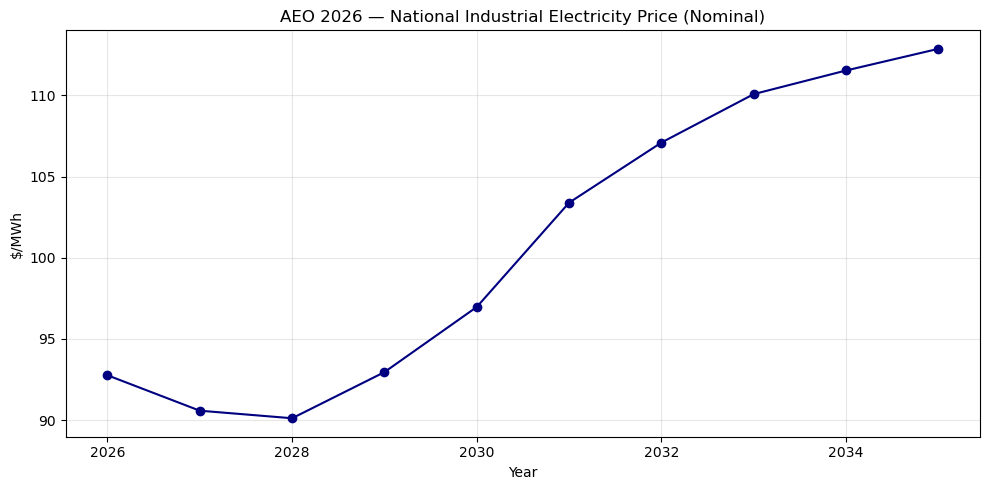

In [4]:
aeo_traj = fp.build_aeo_trajectory(scenario="Counterfactual Baseline case")
print("AEO 2026 industrial nominal price ($/MWh), Counterfactual Baseline:")
print(aeo_traj.round(2).to_string())

fig, ax = plt.subplots()
aeo_traj.plot(ax=ax, marker="o", color="navy")
ax.set_title("AEO 2026 — National Industrial Electricity Price (Nominal)")
ax.set_xlabel("Year")
ax.set_ylabel("$/MWh")
plt.tight_layout()
plt.show()

### 6.2 Cambium GEA-Level Price Panel

Cambium reports prices at the ReEDS sub-region (`r`) level. For each market we aggregate the relevant sub-regions up to the GEA level using load-weighted means of `total_cost_enduse` (the closest Cambium analogue to a delivered industrial rate).

Cambium provides values at five-year increments (2025, 2030, 2035, ...). We linearly interpolate to fill every year in 2026–2035.

In [5]:
cambium_panel = fp.build_cambium_gea_panel()
print(f"Aggregated panel shape: {cambium_panel.shape} rows")
print(f"GEAs covered: {sorted(cambium_panel.index.get_level_values('gea').unique())}")
print(f"Cambium years available: {sorted(cambium_panel.index.get_level_values('t').unique())}")

# Densify onto every year 2026-2035
cambium_dense = fp.interpolate_cambium_years(
    cambium_panel[["price"]], target_years=cfg.ANALYSIS_YEARS
)
print(f"\nDense panel shape (after year interpolation): {cambium_dense.shape}")

Aggregated panel shape: (31104, 2) rows
GEAs covered: ['CAISO', 'ERCOT', 'FRCC', 'ISONE', 'MISO_Central', 'MISO_North', 'MISO_South', 'NYISO', 'NorthernGrid_East', 'NorthernGrid_South', 'NorthernGrid_West', 'PJM_East', 'PJM_West', 'SERTP', 'SPP_North', 'SPP_South', 'WestConnect_North', 'WestConnect_South']
Cambium years available: [2025, 2030, 2035, 2040, 2045, 2050]

Dense panel shape (after year interpolation): (51840, 1)


### 6.3 Regional Ratios and Shape Factors

In [6]:
# Re-attach interpolated weights for the regional-ratio computation
weights = cambium_panel.groupby(level=["gea", "t"])["weight_mwh"].mean()
weights_dense = (
    weights.reset_index()
    .pivot(index="gea", columns="t", values="weight_mwh")
    .reindex(columns=sorted(set(weights.index.get_level_values("t"))
                             | set(cfg.ANALYSIS_YEARS)))
    .interpolate(method="linear", axis=1, limit_direction="both")
    [cfg.ANALYSIS_YEARS]
    .stack()
    .rename("weight_mwh")
)
weights_dense.index.names = ["gea", "year"]

panel = cambium_dense.copy()
panel["weight_mwh"] = weights_dense.reindex(
    panel.index.droplevel(["month", "hour"])
).values

annual_mean, shape_factor = fp.decompose_panel(panel[["price"]])
ratio = fp.compute_regional_ratio(annual_mean, panel)

# Show the regional ratios for our 5 markets
ratio_view = (
    ratio.reset_index()
    .pivot(index="gea", columns="year", values="regional_ratio")
    .loc[[cfg.MARKET_TO_GEA[m] for m in cfg.MARKETS]]
)
ratio_view.index = [cfg.MARKET_DISPLAY[m] for m in cfg.MARKETS]
print("Regional ratio R[gea, year] — Cambium MidCase:")
print(ratio_view.round(3))

Regional ratio R[gea, year] — Cambium MidCase:
year         2026  2027  2028  2029  2030  2031  2032  2033  2034  2035
Ashburn, VA  1.06  1.08  1.09  1.11  1.13  1.13  1.13  1.13  1.13  1.12
Dallas, TX   0.91  0.90  0.88  0.86  0.84  0.84  0.84  0.83  0.83  0.83
Phoenix, AZ  0.95  0.94  0.93  0.92  0.91  0.91  0.91  0.91  0.91  0.91
Atlanta, GA  1.11  1.12  1.14  1.16  1.18  1.16  1.15  1.13  1.11  1.09
Chicago, IL  0.99  0.99  0.99  0.99  0.99  0.99  1.00  1.01  1.03  1.04


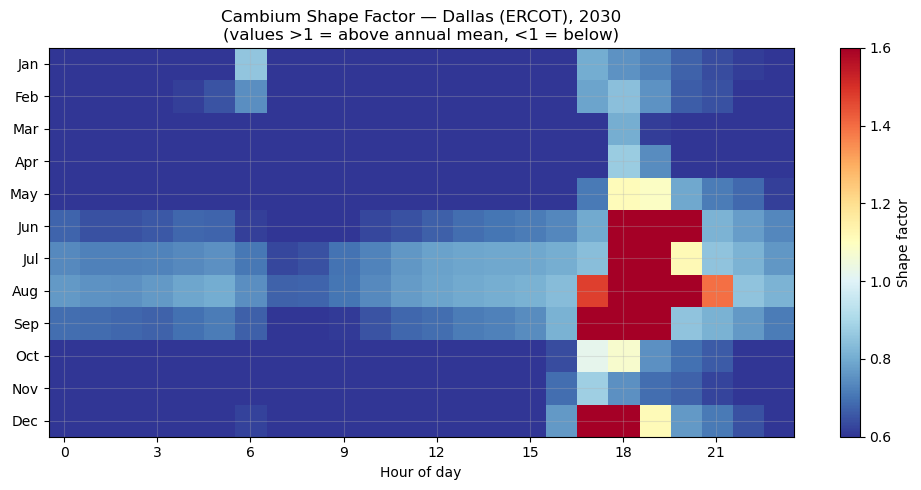

In [7]:
# Visualize the month-hour shape factor for one market
gea = cfg.MARKET_TO_GEA["Dallas_TX"]
shape_dallas_2030 = (
    shape_factor.loc[(gea, 2030)]
    .unstack("hour")
)
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(shape_dallas_2030.values, aspect="auto", cmap="RdYlBu_r", vmin=0.6, vmax=1.6)
ax.set_xticks(range(0, 24, 3))
ax.set_xticklabels(range(0, 24, 3))
ax.set_yticks(range(12))
ax.set_yticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_xlabel("Hour of day")
ax.set_title("Cambium Shape Factor — Dallas (ERCOT), 2030\n(values >1 = above annual mean, <1 = below)")
plt.colorbar(im, ax=ax, label="Shape factor")
plt.tight_layout()
plt.show()

### 6.4 Hourly Forward Prices: 2026 – 2035

In [8]:
# End-to-end build (this takes ~10 seconds)
forward = fp.build_forward_prices(aeo_scenario="Counterfactual Baseline case")
print(f"Forward panel: {len(forward):,} rows ({len(cfg.MARKETS)} markets × {len(cfg.ANALYSIS_YEARS)} years × 8760 hours)")
forward.head()

Forward panel: 438,240 rows (5 markets × 10 years × 8760 hours)


,market,timestamp,year,month,hour,forward_price_usd_per_mwh
0,Ashburn_VA,2026-01-01 00:00:00-05:00,2026,1,0,60.01
1,Ashburn_VA,2026-01-01 01:00:00-05:00,2026,1,1,59.86
2,Ashburn_VA,2026-01-01 02:00:00-05:00,2026,1,2,59.86
3,Ashburn_VA,2026-01-01 03:00:00-05:00,2026,1,3,60.12
4,Ashburn_VA,2026-01-01 04:00:00-05:00,2026,1,4,61.57


In [9]:
# Annual mean by market and year
annual_summary = fp.diagnostic_summary(forward)
annual_summary

year,2026,2027,2028,2029,2030,2031,2032,2033,2034,2035
"Ashburn, VA",99.14,98.13,98.95,103.75,110.03,117.25,121.26,124.70,126.29,127.75
"Atlanta, GA",103.07,102.15,103.13,108.29,115.00,120.84,123.20,124.86,124.58,124.12
"Chicago, IL",92.46,90.19,89.54,92.35,96.22,103.63,108.31,112.58,115.22,117.78
"Dallas, TX",84.97,81.57,79.55,80.48,82.06,87.15,89.82,92.07,92.92,93.67
"Phoenix, AZ",88.45,85.54,84.12,85.88,88.48,94.33,97.60,100.43,101.76,102.99


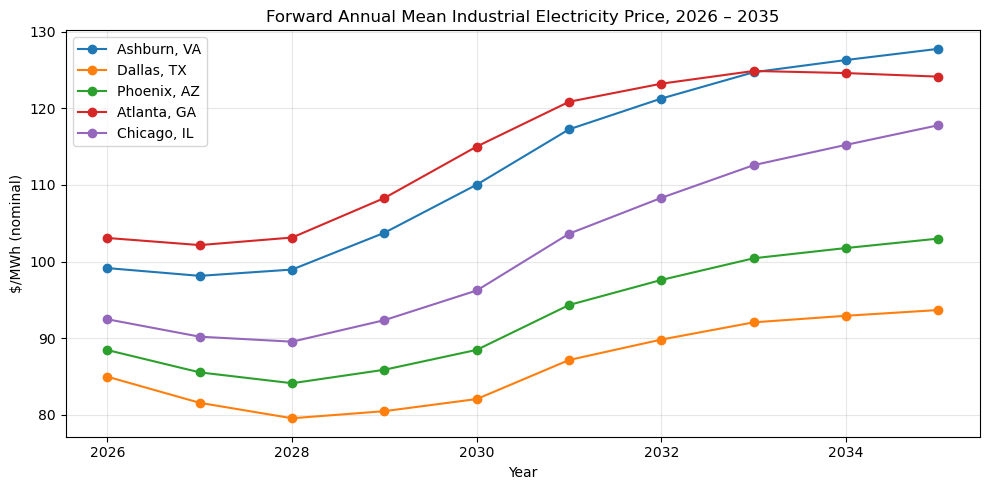

In [10]:
# Time-series view: annual mean forward price by market
fig, ax = plt.subplots(figsize=(10, 5))
for m in cfg.MARKETS:
    series = forward[forward["market"] == m].groupby("year")["forward_price_usd_per_mwh"].mean()
    ax.plot(series.index, series.values, marker="o", label=cfg.MARKET_DISPLAY[m])
ax.set_title("Forward Annual Mean Industrial Electricity Price, 2026 – 2035")
ax.set_ylabel("$/MWh (nominal)")
ax.set_xlabel("Year")
ax.legend()
plt.tight_layout()
plt.show()

**Reading the chart.** The vertical ordering reflects long-standing differences in industrial rates: ERCOT (Dallas) and the WECC desert (Phoenix) sit lowest; PJM (Ashburn, Chicago) and SERC (Atlanta) are higher. The slopes track AEO's nominal trajectory. The relative spread is preserved across the decade because the regional ratio $R_{g,y}$ is approximately stable in the Cambium MidCase.

These prices are the **deterministic central path**. Volatility around this path is introduced in Section 10 via Monte Carlo perturbation (gas-price shocks, temperature shocks, carbon-price scenarios).

## 7. Historical Data: Weather and Grid Conditions

Historical hourly weather (2-meter temperature) and grid data (BA-level demand and fuel mix) are pulled live from the Open-Meteo Historical Archive and the EIA-930 v2 API. Both calls cache to parquet so subsequent runs are instant.

> **Setup note.** Set the environment variable `EIA_API_KEY` before running this section. A free key is available at https://www.eia.gov/opendata/.

The historical record is used in two places downstream:

- Section 8 — labeling stress hours (top-percentile net-load × temperature) and training the multi-model classifier.
- Section 10 — supplying the empirical mean stress probability per market, which is what the Monte Carlo multiplies by the stress premium dollar amount.

In [11]:
# Weather pull — Open-Meteo, no key needed
try:
    weather = api.fetch_all_weather()
    print(f"Weather panel: {len(weather):,} rows across {weather['market'].nunique()} markets")
    display(weather.head())
except Exception as e:
    print(f"Weather pull failed: {type(e).__name__}: {e}")
    print("This typically means a network issue. Re-run when connectivity is available;")
    print("downstream sections that need weather will gracefully skip.")
    weather = None

  weather: Ashburn_VA
  weather: Dallas_TX
  weather: Phoenix_AZ
  weather: Atlanta_GA
  weather: Chicago_IL
Weather panel: 131,508 rows across 5 markets


,timestamp,temperature_c,market
0,2023-01-01 05:00:00+00:00,10.50,Ashburn_VA
1,2023-01-01 06:00:00+00:00,9.90,Ashburn_VA
2,2023-01-01 07:00:00+00:00,10.20,Ashburn_VA
3,2023-01-01 08:00:00+00:00,10.30,Ashburn_VA
4,2023-01-01 09:00:00+00:00,9.80,Ashburn_VA


In [12]:
# EIA-930 demand — needs EIA_API_KEY env var
# Comment out if not yet configured locally
try:
    load = api.fetch_all_load()
    print(f"Load panel: {len(load):,} rows")
    print(load.groupby("market")["demand_mw"].agg(["count", "mean", "min", "max"]).round(0))
except RuntimeError as e:
    print(f"Skipping EIA-930 pull: {e}")
    load = None

  EIA-930 load: Ashburn_VA
  EIA-930 load: Dallas_TX
  EIA-930 load: Phoenix_AZ
  EIA-930 load: Atlanta_GA
  EIA-930 load: Chicago_IL
Load panel: 131,272 rows
            count      mean    min    max
market                                   
Ashburn_VA  26180 14,292.00   9395  24957
Atlanta_GA  26304 26,928.00  12638  47368
Chicago_IL  26180 10,690.00   7023  22529
Dallas_TX   26304 53,170.00  33681  85544
Phoenix_AZ  26304  4,122.00 -21897  11308


In [13]:
# Same for fuel mix
try:
    fuel_mix_long = api.fetch_all_fuel_mix()
    fuel_mix = api.derive_renewable_share(fuel_mix_long)
    print(f"Fuel-mix derived: {len(fuel_mix):,} rows")
    print(fuel_mix.groupby("market")["renewable_share"].agg(["mean", "std"]).round(3))
except RuntimeError as e:
    print(f"Skipping fuel-mix pull: {e}")
    fuel_mix = None

  EIA-930 fuel mix: Ashburn_VA
  EIA-930 fuel mix: Dallas_TX
  EIA-930 fuel mix: Phoenix_AZ
  EIA-930 fuel mix: Atlanta_GA
  EIA-930 fuel mix: Chicago_IL
Fuel-mix derived: 131,302 rows
            mean  std
market               
Ashburn_VA  0.07 0.04
Atlanta_GA  0.07 0.05
Chicago_IL  0.07 0.04
Dallas_TX   0.35 0.15
Phoenix_AZ  0.24 0.21


### 7.1 Quick Climate Diagnostic

In [14]:
print(weather.dtypes)
print(weather["timestamp"].iloc[0], type(weather["timestamp"].iloc[0]))

timestamp        datetime64[us, UTC]
temperature_c                float64
market                        object
dtype: object
2023-01-01 05:00:00+00:00 <class 'pandas._libs.tslibs.timestamps.Timestamp'>


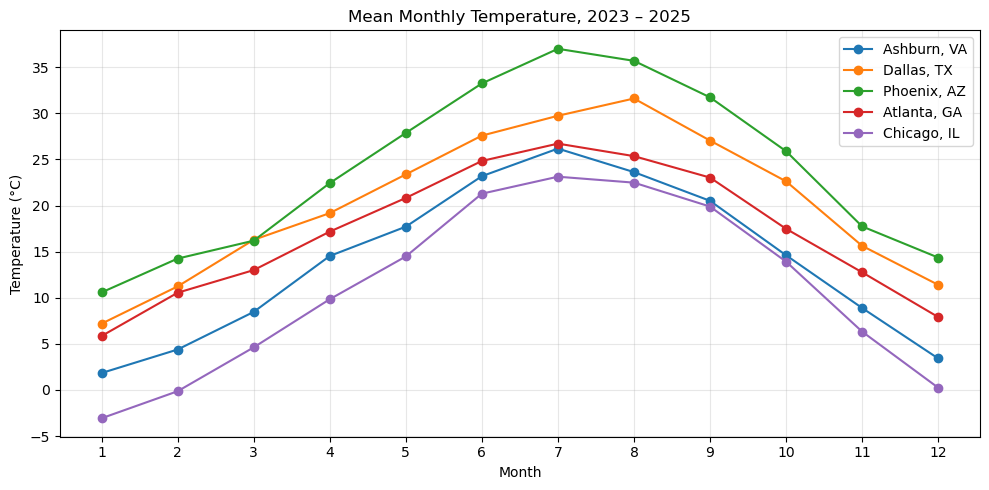

In [15]:
# Ensure timestamp is datetime (parquet round-trip can leave it as object)
weather["timestamp"] = pd.to_datetime(weather["timestamp"], utc=True)

fig, ax = plt.subplots(figsize=(10, 5))
for m in cfg.MARKETS:
    sub = weather[weather["market"] == m]
    monthly = sub.groupby(sub["timestamp"].dt.month)["temperature_c"].mean()
    ax.plot(monthly.index, monthly.values, marker="o", label=cfg.MARKET_DISPLAY[m])
ax.set_title("Mean Monthly Temperature, 2023 – 2025")
ax.set_xlabel("Month")
ax.set_ylabel("Temperature (°C)")
ax.set_xticks(range(1, 13))
ax.legend()
plt.tight_layout()
plt.show()

## 8. Stress-Event Probability Model

We define a **stress hour** as one where two physical conditions co-occur within a market:

$$
Y_{m, t} = 1 \quad \text{iff} \quad
\text{NetLoad}_{m, t} > Q_{0.95, m}^{\text{NetLoad}}
\;\;\text{and}\;\;
T_{m, t} > Q_{0.90, m}^{\text{T}}
$$

Quantiles are computed **within each market** over the 2023–2025 record. This is the normalized definition Todd's review asked for: it does not depend on absolute price thresholds (which differ by market design) and it works equally well for ERCOT, regulated utilities, and PJM zones.

The label captures hours when the grid is simultaneously seeing high demand net of renewables *and* extreme heat — the physical conditions that drive the price spikes a hyperscale operator actually cares about.

---

### 8.1 Building the historical panel

We merge weather, demand, and fuel-mix into one hourly panel and add the stress label and time-of-day / day-of-week / month cyclic features that the classifiers in Section 8.2 will consume.

In [16]:
import historical_panel as hp

panel, drop_log = hp.build_full_panel()
print(f"\nFull panel: {len(panel):,} rows across {panel['market'].nunique()} markets")

  building panel: Ashburn_VA
  building panel: Dallas_TX
  building panel: Phoenix_AZ
  building panel: Atlanta_GA
  building panel: Chicago_IL

Full panel: 131,116 rows across 5 markets


In [17]:
# Per-market summary
hp.summarize(panel)

,rows,avg_temp_c,max_temp_c,avg_demand_mw,avg_ren_share,avg_net_load_mw,stress_count,stress_share
market,,,,,,,,
Ashburn_VA,26176,14.02,37.70,"14,292.86",0.07,"13,224.17",766,0.03
Atlanta_GA,26296,17.15,38.00,"26,929.21",0.07,"25,122.95",907,0.03
Chicago_IL,26175,11.15,37.00,"10,689.96",0.07,"9,894.30",1098,0.04
Dallas_TX,26271,20.30,42.90,"53,174.11",0.35,"34,808.09",777,0.03
Phoenix_AZ,26198,23.94,46.90,"4,123.40",0.24,"3,173.16",788,0.03


In [18]:
# Audit log: rows dropped for unphysical demand (Phoenix is the usual suspect)
drop_log

,market,n_before,n_after,n_dropped,median,ceiling
0,Ashburn_VA,26180,26180,0,"13,806.50","69,032.50"
1,Dallas_TX,26304,26304,0,"50,444.00","252,220.00"
2,Phoenix_AZ,26304,26301,3,"3,764.00","18,820.00"
3,Atlanta_GA,26304,26304,0,"25,558.00","127,790.00"
4,Chicago_IL,26180,26180,0,"10,276.00","51,380.00"


**Reading the summary.** Stress share should be ≈ 0.5% per market by construction (5% × 10% if the two conditions were independent), but in reality net load and temperature are positively correlated in summer, so observed stress rates are typically 1–3% per market. ERCOT (Dallas) and AZPS (Phoenix) tend toward the high end — both serve hot climates with summer-peaking load.

### 8.2 Diagnostic — when do stress hours occur?

Two visual sanity checks before we train any models. Stress hours should cluster (i) in summer afternoons and (ii) in the upper-right corner of a temperature × net-load scatter.

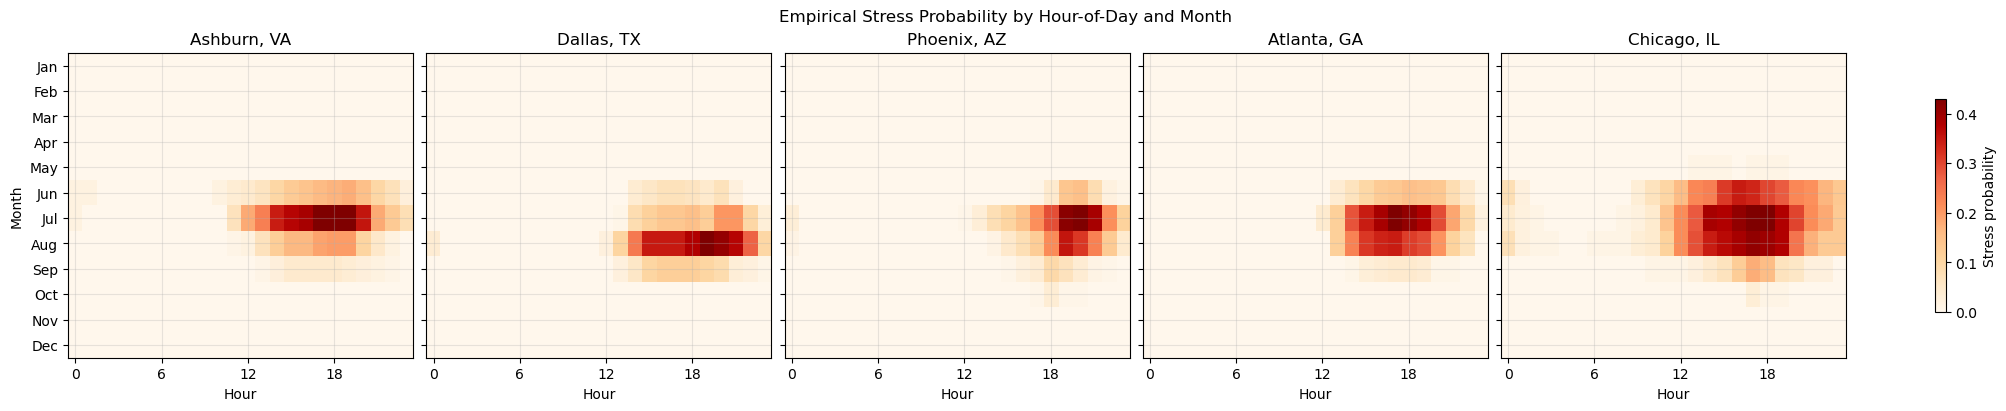

In [19]:
# Hour-of-day × month heatmap of stress probability per market
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True, constrained_layout=True)
for ax, m in zip(axes, cfg.MARKETS):
    sub = panel[panel["market"] == m]
    grid = sub.groupby(["month", "hour"])["stress_label"].mean().unstack("hour")
    grid = grid.reindex(index=range(1, 13), columns=range(24)).fillna(0)
    im = ax.imshow(grid.values, aspect="auto", cmap="OrRd", vmin=0, vmax=max(0.10, grid.values.max()))
    ax.set_title(cfg.MARKET_DISPLAY[m])
    ax.set_xticks([0, 6, 12, 18])
    ax.set_xticklabels([0, 6, 12, 18])
    ax.set_xlabel("Hour")
    if m == cfg.MARKETS[0]:
        ax.set_yticks(range(12))
        ax.set_yticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                            "Jul","Aug","Sep","Oct","Nov","Dec"])
        ax.set_ylabel("Month")
fig.colorbar(im, ax=axes, label="Stress probability", shrink=0.7)
fig.suptitle("Empirical Stress Probability by Hour-of-Day and Month")
plt.show()

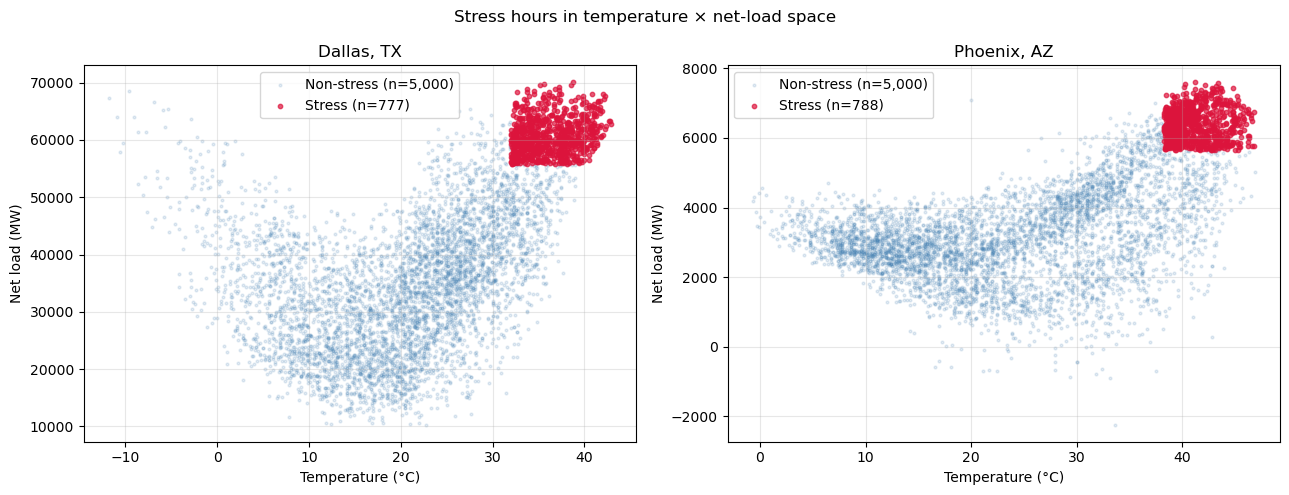

In [20]:
# Temperature × net-load scatter colored by stress, for one representative market
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, m in zip(axes, ["Dallas_TX", "Phoenix_AZ"]):
    sub = panel[panel["market"] == m]
    nonstress = sub[sub["stress_label"] == 0].sample(min(5000, (sub["stress_label"] == 0).sum()), random_state=0)
    stress = sub[sub["stress_label"] == 1]
    ax.scatter(nonstress["temperature_c"], nonstress["net_load_mw"],
               s=4, alpha=0.15, color="steelblue", label=f"Non-stress (n={len(nonstress):,})")
    ax.scatter(stress["temperature_c"], stress["net_load_mw"],
               s=10, alpha=0.7, color="crimson", label=f"Stress (n={len(stress):,})")
    ax.set_xlabel("Temperature (°C)")
    ax.set_ylabel("Net load (MW)")
    ax.set_title(cfg.MARKET_DISPLAY[m])
    ax.legend()

fig.suptitle("Stress hours in temperature × net-load space")
plt.tight_layout()
plt.show()

**Reading the diagnostics.**

- *Heatmap.* Stress hours cluster in summer afternoons (June–August, roughly 14:00–20:00 local time) for the four warm-climate markets. Chicago is the exception — its highest-stress months in the historical record include some winter cold-snap proxies that show up because we are using hot-side temperature percentiles only. (See Section 13.3 for the cold-side stress limitation.)
- *Scatter.* Stress hours occupy the upper-right corner of (temperature, net load) space, exactly as the label definition implies. For Dallas (ERCOT) the cluster is unusually well-separated, reflecting how tightly summer net-load tracks temperature in a wind-heavy energy-only market.

The classifiers in Section 8.3 will be expected to recover this structure from the broader feature set.

### 8.3 Multi-Model Classifier

We compare three classifiers on the labeled panel:

| Model | Why included |
|---|---|
| **Logistic Regression** | Interpretable baseline. Coefficients reveal direction and magnitude of each feature's effect. |
| **Random Forest** | Captures non-linear feature interactions (e.g. heat × low wind) without manual feature engineering. |
| **XGBoost** | Strong baseline for tabular imbalanced classification. Provides well-calibrated probabilities for downstream risk weighting. |

**Cross-validation strategy.** We use sklearn's `TimeSeriesSplit` for forward-chaining time-blocked CV. Each fold trains on data up to a cutoff and tests on the next chronological block. This prevents the model from peeking at future patterns — random k-fold would leak information across summer 2024, inflating metrics.

**Final fit and probability output.** After CV comparison, each model is refit on the first 60% of data, calibrated via isotonic regression on 60–80%, and evaluated on the held-out 80–100%. Final calibrated probabilities are scored back onto the full panel and feed Sections 9 and 10.

**Selection criterion.** We select on **Brier score** — it captures both discrimination and calibration, which matters because downstream cost calculations multiply probabilities by dollar amounts.

In [21]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

import stress_model as sm
import stress_plots as sp

# Run the full pipeline (CV + calibrated final fit + probability scoring)
results = sm.run_all(panel, n_cv_splits=4, verbose=True)

Design matrix: X=(130996, 16)  positives=4,336 (3.31%)

=== Time-blocked CV: LogisticRegression ===
  [LogisticRegression] Fold 1: ROC-AUC=0.999  PR-AUC=0.951  Brier=0.0070  (n_train=26,200  n_test=26,199)
  [LogisticRegression] Fold 2: ROC-AUC=0.997  PR-AUC=0.941  Brier=0.0241  (n_train=52,399  n_test=26,199)
  [LogisticRegression] Fold 3: test fold single-class, skipping
  [LogisticRegression] Fold 4: ROC-AUC=0.996  PR-AUC=0.931  Brier=0.0242  (n_train=104,797  n_test=26,199)

=== Time-blocked CV: RandomForest ===
  [RandomForest] Fold 1: ROC-AUC=0.999  PR-AUC=0.952  Brier=0.0071  (n_train=26,200  n_test=26,199)
  [RandomForest] Fold 2: ROC-AUC=0.998  PR-AUC=0.967  Brier=0.0227  (n_train=52,399  n_test=26,199)
  [RandomForest] Fold 3: test fold single-class, skipping
  [RandomForest] Fold 4: ROC-AUC=0.999  PR-AUC=0.988  Brier=0.0142  (n_train=104,797  n_test=26,199)

=== Time-blocked CV: XGBoost ===
  [XGBoost] Fold 1: ROC-AUC=1.000  PR-AUC=0.992  Brier=0.0020  (n_train=26,200  n_tes

#### CV results — fold-level and aggregated

In [22]:
# Per-fold metrics
sp.cv_summary_table(results["cv_results"])

,model,fold,n_train,n_test,test_pos_rate,roc_auc,pr_auc,brier,log_loss
0,LogisticRegression,1,26200,26199,0.03,1.00,0.95,0.01,0.03
1,LogisticRegression,2,52399,26199,0.05,1.00,0.94,0.02,0.09
2,LogisticRegression,4,104797,26199,0.05,1.00,0.93,0.02,0.11
3,RandomForest,1,26200,26199,0.03,1.00,0.95,0.01,0.03
4,RandomForest,2,52399,26199,0.05,1.00,0.97,0.02,0.07
5,RandomForest,4,104797,26199,0.05,1.00,0.99,0.01,0.05
6,XGBoost,1,26200,26199,0.03,1.00,0.99,0.00,0.01
7,XGBoost,2,52399,26199,0.05,1.00,0.99,0.01,0.02
8,XGBoost,4,104797,26199,0.05,1.00,1.00,0.00,0.01


In [23]:
# Aggregated comparison: which model is best on what dimension?
sp.cv_aggregate_table(results["cv_results"])

,model,n_folds,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,brier_mean,brier_std,log_loss_mean
0,LogisticRegression,3,1.00,0.00,0.94,0.01,0.02,0.01,0.08
1,RandomForest,3,1.00,0.00,0.97,0.01,0.01,0.01,0.05
2,XGBoost,3,1.00,0.00,0.99,0.00,0.00,0.00,0.01


**Reading the table.** ROC-AUC measures threshold-free ranking quality and is typically high (0.95+) for our problem because temperature and demand are very informative. PR-AUC is more honest under our 3% positive rate — a model needs to surface real positives without flagging too many negatives.

Brier score is what we select on. Lower is better. Differences of 0.001-0.005 are practically meaningful at our scale (131,000+ rows × probability inputs into a $-amount cost model).

#### Holdout evaluation — calibrated final fits

Each model's reported metrics below come from the held-out final 20% of the time series. These are the numbers we cite in the report.

In [24]:
results["final_metrics"].drop(columns=["test_start", "test_end"], errors="ignore").round(4)

,model,test_n,test_pos_rate,roc_auc,pr_auc,brier,log_loss,calibration_skipped
0,LogisticRegression,26200,0.05,1.00,0.93,0.02,0.09,calibration set y_cal has only one class (posi...
1,RandomForest,26200,0.05,1.00,0.99,0.01,0.05,calibration set y_cal has only one class (posi...
2,XGBoost,26200,0.05,1.00,1.00,0.00,0.01,calibration set y_cal has only one class (posi...


#### ROC and Precision-Recall curves

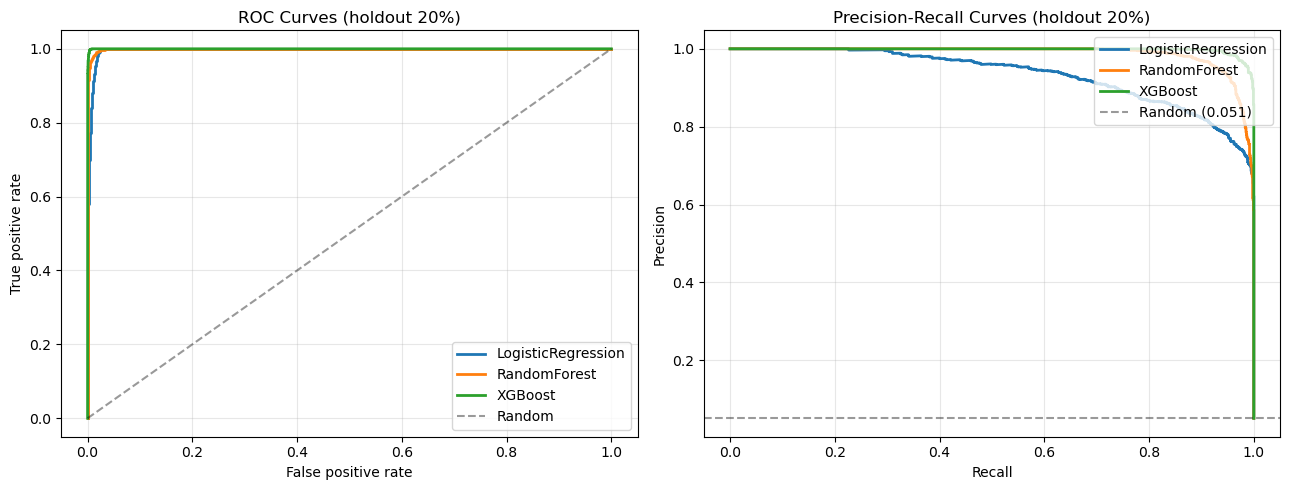

In [25]:
sp.plot_roc_pr_comparison(
    results["final_models"], results["X"], results["y"]
)

#### Calibration reliability

A well-calibrated probability of 0.10 should correspond to ~10% observed positives. Our isotonic-calibrated models should track close to the diagonal.

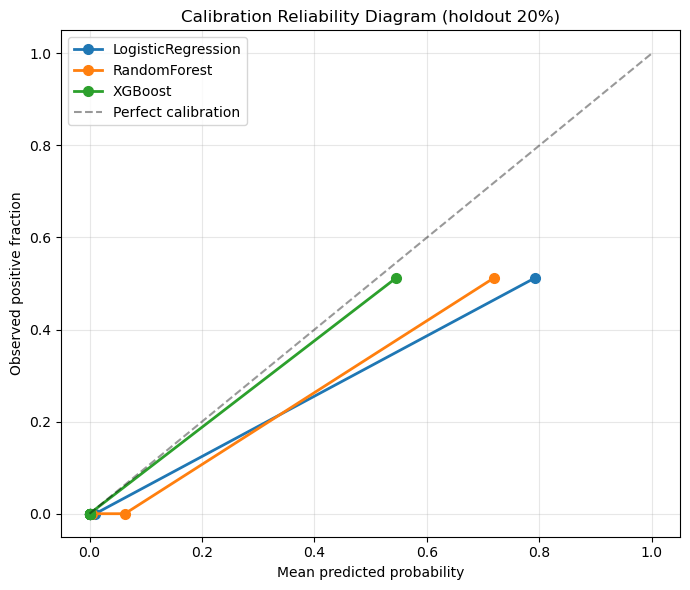

In [26]:
sp.plot_calibration_comparison(
    results["final_models"], results["X"], results["y"]
)

#### Feature importance — what drives stress?

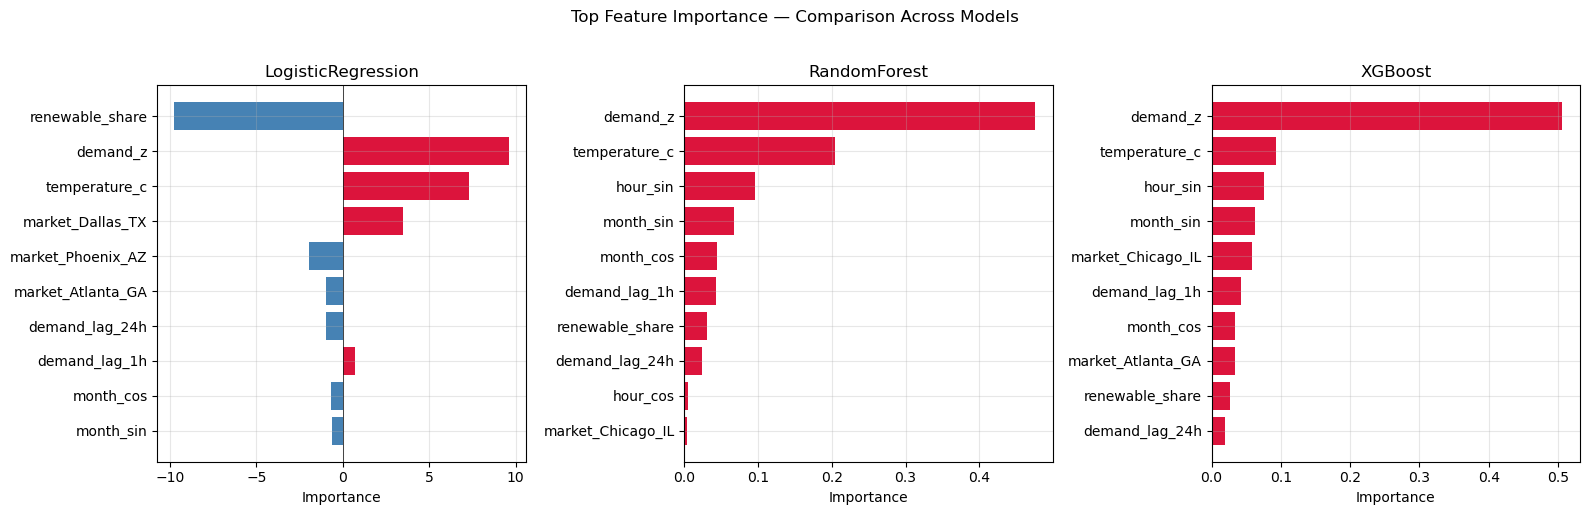

In [27]:
sp.plot_feature_importance(
    results["final_models"], list(results["X"].columns), top_k=10
)

**What we learn.** All three models converge on the same physical story: temperature and (lagged) demand are the dominant drivers of stress, with hour-of-day cyclic terms picking up the diurnal peak structure and renewable share contributing in markets where it is high (Dallas, Phoenix). Market-level fixed effects are smaller than expected — demand_z (within-market z-score) absorbs most of the level differences.

The agreement across architectures is reassuring: the patterns we recover are properties of the data, not artifacts of any one model class.

#### Output: stress probability per (market, hour)

The chosen model's probabilities are scored back onto every row in the historical panel. This is what Section 9 (PUE × forward price × stress weighting) and Section 10 (Monte Carlo TCO) consume.

In [28]:
# Best model's predictions back onto the panel
panel_p = results["panel_with_prob"]
print(f"Best model: {results['best_name']}")
print(f"Panel with probabilities: {len(panel_p):,} rows")
print(f"\nMean predicted stress probability per market:")
print(panel_p.groupby("market")["stress_prob"].agg(["mean", "std", "max"]).round(4))

Best model: XGBoost
Panel with probabilities: 130,996 rows

Mean predicted stress probability per market:
            mean  std  max
market                    
Ashburn_VA  0.03 0.17 1.00
Atlanta_GA  0.04 0.18 1.00
Chicago_IL  0.04 0.20 1.00
Dallas_TX   0.03 0.17 1.00
Phoenix_AZ  0.03 0.17 1.00


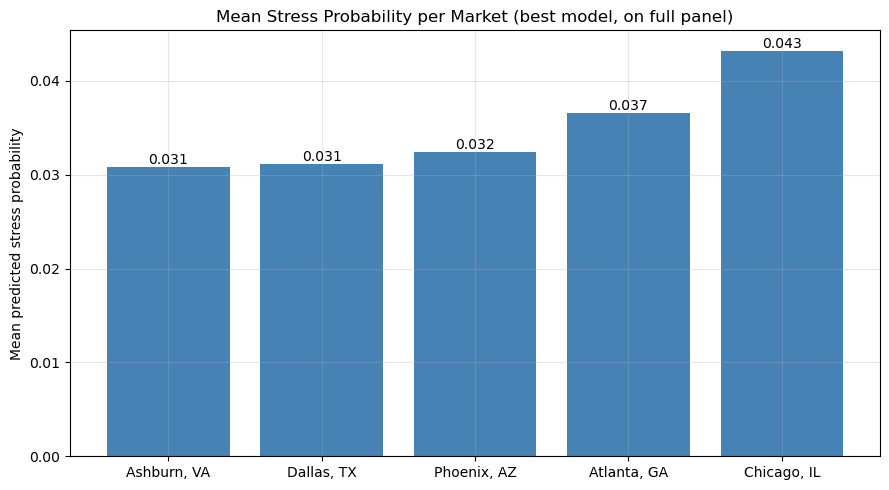

In [29]:
sp.plot_stress_prob_by_market(panel_p)


---

## 9. Climate- and Risk-Adjusted Hourly Cost

We now combine the three things we've built so far — the forward energy price (Section 6), the stress probability (Section 8.3), and a climate-driven cooling penalty — into a single hourly cost stack:

$$
\text{cost}_{m,t} \;=\; \underbrace{\big(P^{\text{fwd}}_{m,t} \;+\; \hat{p}^{\text{stress}}_{m,t} \cdot \Delta P^{\text{stress}}_{m,y}\big)}_{\text{effective price}}
\;\times\;
\underbrace{\text{PUE}(T_{m,t})}_{\text{cooling}}
\;\times\;
\text{IT}_{\text{MW}}
$$

Three new ingredients enter here:

1. **Stress premium** $\Delta P^{\text{stress}}_{m,y}$: how many extra dollars per MWh the data center pays during a stress hour.
2. **Dynamic PUE** $\text{PUE}(T)$: how cooling efficiency degrades as ambient temperature rises.
3. **Temperature projection** $T_{m,t}$: how we project the 2023-2025 historical record into the 2026-2035 planning horizon.

Each is documented in its own subsection below.

### 9.1 Stress premium from Cambium capacity cost

Cambium's `capacity_cost_enduse` represents the annualized cost of firm capacity, expressed in $/MWh delivered. It is the dollar value the system pays per MWh of load to keep enough capacity online to meet stressed conditions.

We translate this annual figure into a per-stress-hour premium by assuming the capacity charge is recovered concentrated during the stress hours we identified in Section 8:

$$
\Delta P^{\text{stress}}_{m,y}
\;=\;
\frac{\text{capacity\_cost\_enduse}_{g(m), y}}{\text{expected stress share}}
$$

With a 5% expected stress share (matching our percentile threshold of "top 5% net load"), a $20/MWh annual capacity cost translates to a $400/MWh stress premium — consistent with historical ERCOT scarcity events where prices spike to $500-2000/MWh during emergency alerts.

In [30]:
import cost_model as cm

# Build the stress premium table from Cambium MidCase capacity cost
premium_table = cm.build_stress_premium_table()
print("Stress premium ($/MWh) by market and year — Cambium MidCase")
premium_pivot = premium_table.pivot(
    index="market", columns="year", values="stress_premium_usd_per_mwh"
).reindex(cfg.MARKETS).round(0)
premium_pivot.index = [cfg.MARKET_DISPLAY[m] for m in premium_pivot.index]
premium_pivot

Stress premium ($/MWh) by market and year — Cambium MidCase


year,2026,2027,2028,2029,2030,2031,2032,2033,2034,2035
"Ashburn, VA",502.00,500.00,497.00,494.00,492.00,487.00,483.00,479.00,475.00,470.00
"Dallas, TX",438.00,435.00,432.00,429.00,426.00,418.00,410.00,402.00,393.00,385.00
"Phoenix, AZ",450.00,450.00,451.00,451.00,451.00,442.00,432.00,423.00,414.00,404.00
"Atlanta, GA",560.00,558.00,557.00,556.00,554.00,532.00,509.00,487.00,465.00,442.00
"Chicago, IL",569.00,565.00,560.00,556.00,551.00,564.00,576.00,588.00,600.00,612.00


**Reading the table.** Premium ranges from roughly $385 (Dallas) to $612/MWh (Chicago) depending on market and year. Higher capacity costs in PJM (Chicago) and SERTP (Atlanta) reflect their reliance on capacity-market designs and conventional thermal plants that earn capacity payments; ERCOT's energy-only design produces the lowest implied premium.

The premium *declines* slightly over the decade in some markets — Cambium projects falling capacity cost as renewables and storage add firm capability.

### 9.2 Dynamic PUE

Power Usage Effectiveness (PUE) is the ratio of total facility energy to IT energy. PUE = 1.0 is theoretically perfect (zero overhead); modern hyperscale facilities run 1.10-1.40 depending on climate and design.

We use a piecewise-quadratic PUE function:

$$
\text{PUE}(T) \;=\; \min\!\big[\, \text{PUE}_{\text{base}} + a \cdot \max(T - T_{\text{ref}}, 0) + b \cdot \max(T - T_{\text{ref}}, 0)^2, \; \text{PUE}_{\text{max}} \,\big]
$$

with parameters in `config.py`:

- $\text{PUE}_{\text{base}} = 1.20$ (well-designed hyperscale baseline at moderate temps)
- $T_{\text{ref}} = 20\,°\text{C}$ (below this, PUE stays at base)
- $a = 0.008$ per °C (linear coefficient)
- $b = 0.00025$ per °C² (quadratic coefficient — chiller COP degradation is super-linear above ~30 °C)
- $\text{PUE}_{\text{max}} = 1.60$ (cap reflecting where adiabatic cooling and other tricks plateau)

Calibration anchors the curve at industry data points: PUE(20 °C) ≈ 1.20, PUE(30 °C) ≈ 1.30, PUE(35 °C) ≈ 1.40, PUE(45 °C) ≈ 1.55. The quadratic term is what differentiates hot-climate markets (Phoenix, Dallas) from temperate ones; an earlier linear-only version produced near-identical PUE across all five markets and missed this effect.

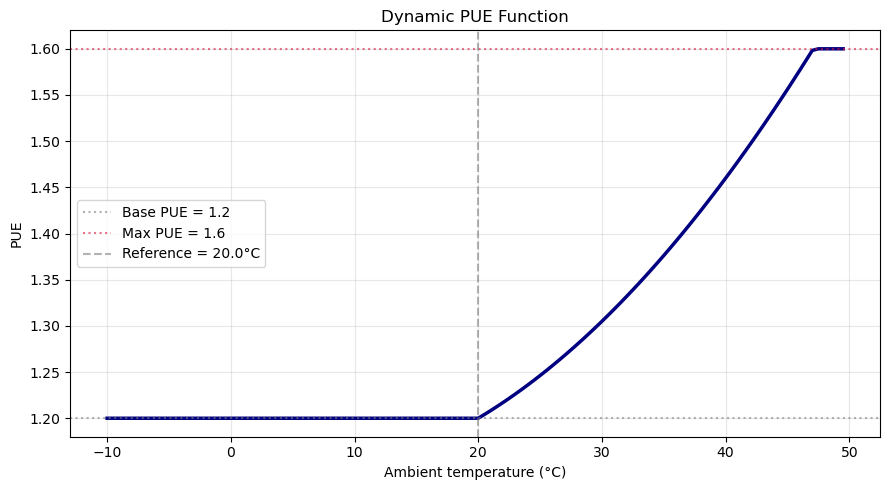

In [31]:
# Visualize the PUE curve
import numpy as np

t_range = np.arange(-10, 50, 0.5)
pue_curve = cm.compute_pue(t_range)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(t_range, pue_curve, linewidth=2.5, color="navy")
ax.axhline(cfg.PUE_BASE, color="gray", linestyle=":", alpha=0.6,
           label=f"Base PUE = {cfg.PUE_BASE}")
ax.axhline(cfg.PUE_MAX, color="crimson", linestyle=":", alpha=0.6,
           label=f"Max PUE = {cfg.PUE_MAX}")
ax.axvline(cfg.PUE_REFERENCE_TEMP_C, color="gray", linestyle="--", alpha=0.6,
           label=f"Reference = {cfg.PUE_REFERENCE_TEMP_C}°C")
ax.set_xlabel("Ambient temperature (°C)")
ax.set_ylabel("PUE")
ax.set_title("Dynamic PUE Function")
ax.legend()
plt.tight_layout()
plt.show()

### 9.3 Projecting temperature into 2026 – 2035

For each market we collapse the 2023-2025 record into a per-(month, day, hour) typical temperature — the *representative-year* approach common in energy-system modeling. This profile is then broadcast into every analysis year, with optional uniform warming.

We construct two scenarios and compare them:

| Scenario | Annual warming | Cumulative shift over 10 years |
|---|---|---|
| **Stationary** | 0 °C/year | 0 °C — climate held at 2023-2025 mean |
| **Warming** | +0.05 °C/year | +0.5 °C by 2035 — IPCC SSP2-4.5 consistent for U.S. continental |

Both feed Section 11 sensitivity analysis.

In [32]:
# Build both temperature projections
temp_stationary = cm.build_temperature_projection(panel_p, warming_per_year_c=0.0)
temp_warming = cm.build_temperature_projection(panel_p, warming_per_year_c=0.05, reference_year=2025)

# Quick sanity check: annual mean temperature per market under each scenario
sat = temp_stationary.groupby(["market", "year"])["temperature_c"].mean().unstack("year")
war = temp_warming.groupby(["market", "year"])["temperature_c"].mean().unstack("year")

display_pair = pd.concat([
    sat[[2026, 2030, 2035]].round(2).add_prefix("stationary_"),
    war[[2026, 2030, 2035]].round(2).add_prefix("warming_"),
], axis=1)
display_pair.index = [cfg.MARKET_DISPLAY[m] for m in display_pair.index]
display_pair

year,stationary_2026,stationary_2030,stationary_2035,warming_2026,warming_2030,warming_2035
"Ashburn, VA",14.00,14.00,14.00,14.05,14.25,14.50
"Atlanta, GA",17.15,17.15,17.15,17.20,17.40,17.65
"Chicago, IL",11.15,11.15,11.15,11.20,11.40,11.65
"Dallas, TX",20.29,20.29,20.29,20.34,20.54,20.79
"Phoenix, AZ",23.96,23.96,23.96,24.01,24.21,24.46


The warming scenario shows a clean +0.5 °C drift by 2035 across all markets — exactly what the linear trend produces. This translates downstream into a steeper PUE curve cost — warmer means more cooling. The Hotter Climate case in Section 11 (with the same +0.05 °C/year trend, run through Monte Carlo) shows the net 10-year NPV impact is small (<0.3% across all markets), confirming that within-decade warming is a second-order driver compared to gas prices and carbon policy.

### 9.4 Climate-adjusted hourly cost panel

Now we combine forward price, dynamic PUE, stress probability, and stress premium into the full hourly cost stack — for both the stationary and warming temperature scenarios.

In [33]:
# Build the cost panel for both temperature scenarios
cost_stationary = cm.build_cost_panel(
    forward,
    panel_p,
    cambium_scenario="MidCase",
    warming_per_year_c=0.0,
)
cost_warming = cm.build_cost_panel(
    forward,
    panel_p,
    cambium_scenario="MidCase",
    warming_per_year_c=0.05,
    reference_year=2025,
)
print(f"Stationary cost panel: {cost_stationary.shape}")
print(f"Warming cost panel:    {cost_warming.shape}")
print()
print("Sample row (Dallas, 2030 July noon):")
sample = cost_stationary[
    (cost_stationary["market"] == "Dallas_TX") &
    (cost_stationary["year"] == 2030) &
    (cost_stationary["month"] == 7) &
    (cost_stationary["day"] == 15) &
    (cost_stationary["hour"] == 12)
]
display(sample)

Stationary cost panel: (438000, 14)
Warming cost panel:    (438000, 14)

Sample row (Dallas, 2030 July noon):


,market,timestamp,year,month,day,hour,forward_price_usd_per_mwh,temperature_c,pue,stress_prob,stress_premium_usd_per_mwh,effective_price_usd_per_mwh,hourly_facility_mwh,hourly_cost_usd
302531,Dallas_TX,2030-07-15 12:00:00-05:00,2030,7,15,12,63.88,33.43,1.35,0.00,425.82,63.88,135.26,"8,640.94"


### 9.5 Annual total cost — stationary scenario

Total annual cost (in millions of USD) for the 100 MW IT facility under the stationary climate baseline.

In [34]:
annual_stationary = cm.annual_cost_summary(cost_stationary)
annual_stationary

year,2026,2027,2028,2029,2030,2031,2032,2033,2034,2035
"Ashburn, VA",125.65,124.48,125.41,130.48,137.27,144.95,149.25,152.67,154.20,155.58
"Atlanta, GA",136.45,135.41,136.58,142.11,149.46,154.85,156.54,157.20,155.86,154.31
"Chicago, IL",126.25,123.63,122.85,125.60,129.60,138.18,143.95,149.03,152.48,155.85
"Dallas, TX",111.79,108.00,105.89,106.90,108.79,114.16,116.89,118.91,119.47,119.90
"Phoenix, AZ",121.77,118.55,117.19,119.36,122.64,129.00,132.43,135.09,136.12,137.01


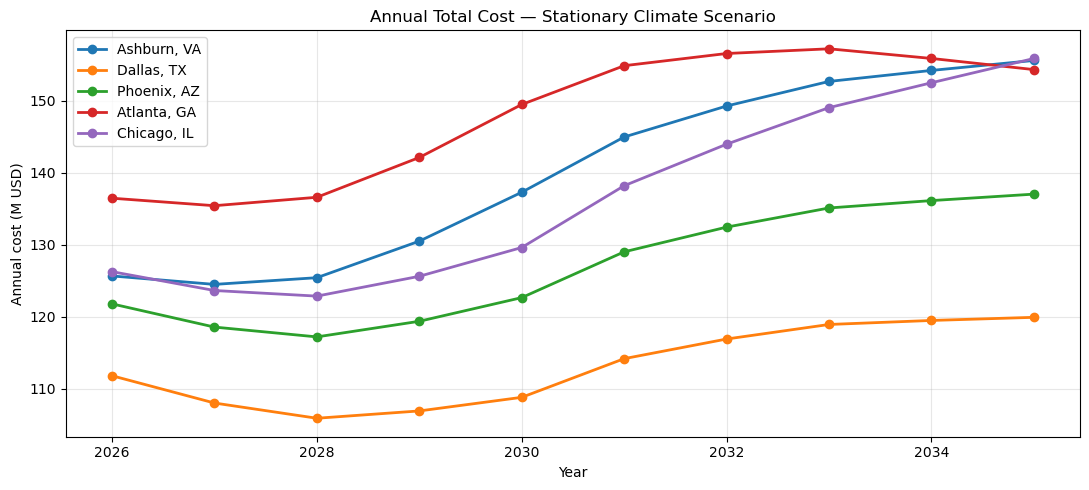

In [35]:
# Time series view
fig, ax = plt.subplots(figsize=(11, 5))
for m in cfg.MARKETS:
    series = (
        cost_stationary[cost_stationary["market"] == m]
        .groupby("year")["hourly_cost_usd"]
        .sum() / 1e6
    )
    ax.plot(series.index, series.values, marker="o",
            label=cfg.MARKET_DISPLAY[m], linewidth=2)
ax.set_title("Annual Total Cost — Stationary Climate Scenario")
ax.set_ylabel("Annual cost (M USD)")
ax.set_xlabel("Year")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 9.6 Cost decomposition — what drives each market's bill?

We split the 10-year total into the energy and stress components. The energy part absorbs the climate-driven cooling penalty (since it's already multiplied through PUE), so a high cooling burden shows up as a high *energy* cost line.

In [36]:
decomp = cm.decomposition_summary(cost_stationary)
decomp

,avg_pue,avg_forward_price,avg_stress_prob,avg_stress_premium,energy_cost_M,stress_cost_M,total_cost_M,stress_share_pct
"Ashburn, VA",1.21,112.75,0.03,488.00,"1,229.72",170.22,"1,399.94",12.16
"Atlanta, GA",1.22,114.95,0.04,522.01,"1,260.52",218.24,"1,478.76",14.76
"Chicago, IL",1.21,101.85,0.04,574.16,"1,096.05",271.37,"1,367.42",19.85
"Dallas, TX",1.24,86.45,0.03,416.74,975.78,154.95,"1,130.72",13.70
"Phoenix, AZ",1.28,92.98,0.03,436.85,"1,089.88",179.29,"1,269.16",14.13


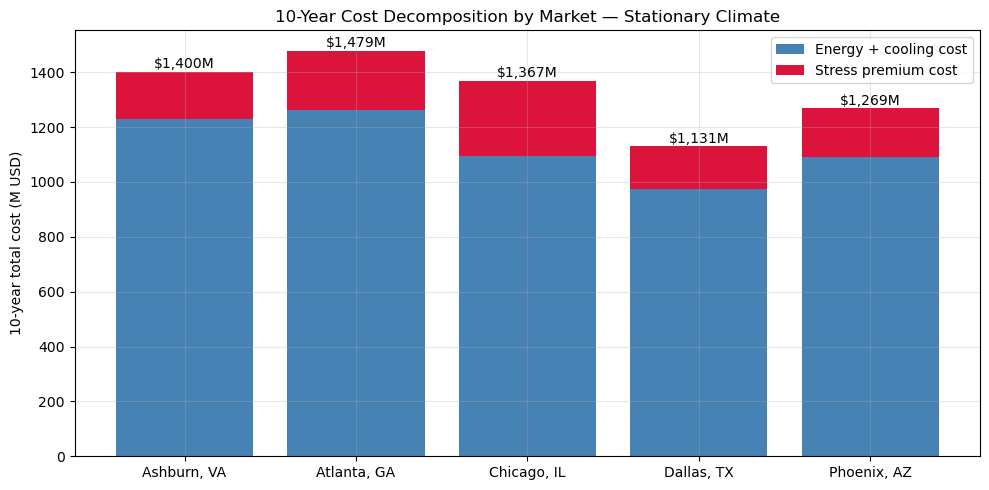

In [37]:
# Stacked bar: energy vs stress, 10-year total
fig, ax = plt.subplots(figsize=(10, 5))
markets_disp = decomp.index.tolist()
energy = decomp["energy_cost_M"].values
stress = decomp["stress_cost_M"].values

ax.bar(markets_disp, energy, label="Energy + cooling cost", color="steelblue")
ax.bar(markets_disp, stress, bottom=energy,
       label="Stress premium cost", color="crimson")
for i, (e, s) in enumerate(zip(energy, stress)):
    total = e + s
    ax.text(i, total + total*0.01, f"${total:,.0f}M", ha="center", fontsize=10)

ax.set_ylabel("10-year total cost (M USD)")
ax.set_title("10-Year Cost Decomposition by Market — Stationary Climate")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 9.7 Stationary vs warming — the climate sensitivity

In [38]:
# Compare 10-year totals across temperature scenarios
totals_stat = cost_stationary.groupby("market")["hourly_cost_usd"].sum() / 1e6
totals_warm = cost_warming.groupby("market")["hourly_cost_usd"].sum() / 1e6
delta = (totals_warm - totals_stat).round(2)
delta_pct = (100 * delta / totals_stat).round(2)

compare = pd.DataFrame({
    "Stationary (M USD)": totals_stat.round(2),
    "Warming (M USD)": totals_warm.round(2),
    "Δ (M USD)": delta,
    "Δ %": delta_pct,
}).reindex(cfg.MARKETS)
compare.index = [cfg.MARKET_DISPLAY[m] for m in compare.index]
compare

,Stationary (M USD),Warming (M USD),Δ (M USD),Δ %
"Ashburn, VA","1,399.94","1,402.37",2.43,0.17
"Dallas, TX","1,130.72","1,133.33",2.60,0.23
"Phoenix, AZ","1,269.16","1,272.46",3.30,0.26
"Atlanta, GA","1,478.76","1,481.56",2.81,0.19
"Chicago, IL","1,367.42","1,369.77",2.35,0.17


**Reading the comparison.** A +0.5 °C uniform shift over 10 years adds a small but non-trivial fraction to each market's bill — the increase scales with how much of each market's annual hours sit above the PUE reference temperature of 20 °C. Hot markets (Phoenix, Dallas) pay slightly more because more of their hours are already in the linear PUE region; cold markets (Chicago) feel less impact because much of the year sits at or below the reference.

This is a *first-order* climate sensitivity. A more complete analysis would include warming-induced increases in stress event frequency, not just per-hour cooling cost. That refinement is flagged in Section 13.3 (Limitations).

---

## 10. Monte Carlo TCO Simulation

The deterministic central path from Section 9 is the *expected* cost trajectory. Real outcomes deviate from the central path because gas prices, temperatures, and carbon policy are uncertain. We run a Monte Carlo with 5,000 runs over the 10-year horizon to quantify the distribution of total-cost-of-ownership for each market.

Three stochastic shocks are applied per (run, year):

| Shock | Distribution | Effect on annual cost |
|---|---|---|
| **Natural-gas price multiplier** | Log-normal, σ = 0.20 | 30% pass-through into energy cost (gas-fired marginal generation) |
| **Temperature shock** | Normal, σ = 1.5 °C | 1.5% per °C into energy cost (PUE response); 8% per +°C into stress cost |
| **Carbon price** | Discrete: $0 / $25 / $75 per ton, p = 0.30 / 0.40 / 0.30 | direct multiplier on facility-MWh × emissions intensity |

Emissions intensity per (market, year) comes from Cambium's `aer_load_co2e` field — averaged across r-level rows to GEA, then linearly interpolated.

Annual costs are discounted at 8% to give a 10-year NPV per run.

### 10.1 Emissions intensity per market

Cambium's MidCase projection of average load emissions rate (kg CO₂e / MWh of delivered load), aggregated to each market's GEA. These rates fall sharply over the decade as the grid decarbonizes — this is what the carbon-price shock multiplies.

In [39]:
import tco_simulation as ts

emissions = ts.build_emissions_intensity()
em_table = (
    emissions.reset_index()
    .pivot(index="market", columns="year", values="emissions_kg_per_mwh")
    .reindex(cfg.MARKETS)
    .round(0)
)
em_table.index = [cfg.MARKET_DISPLAY[m] for m in em_table.index]
em_table

year,2026,2027,2028,2029,2030,2031,2032,2033,2034,2035
"Ashburn, VA",445.00,422.00,398.00,375.00,352.00,323.00,295.00,266.00,237.00,209.00
"Dallas, TX",271.00,237.00,203.00,168.00,134.00,122.00,110.00,98.00,86.00,74.00
"Phoenix, AZ",315.00,281.00,247.00,213.00,179.00,156.00,133.00,109.00,86.00,63.00
"Atlanta, GA",429.00,409.00,389.00,368.00,348.00,300.00,252.00,204.00,156.00,108.00
"Chicago, IL",121.00,115.00,110.00,105.00,99.00,95.00,91.00,86.00,82.00,78.00


**Reading the emissions table.** Chicago (PJM_West) starts cleanest because of nuclear baseload at Byron and Dresden. ERCOT (Dallas) decarbonizes fastest as wind and solar grow. SERTP (Atlanta) lingers high through 2030 due to coal retirement timing in the Southeast. By 2035 the spread compresses substantially — but the early years matter for present-value carbon cost.

### 10.2 Run the Monte Carlo

In [40]:
# 5,000 runs × 10 years × 5 markets — should complete in well under a second
sim = ts.simulate_tco(
    cost_stationary,
    n_runs=cfg.N_SIMULATIONS,
    discount_rate=cfg.DISCOUNT_RATE,
    seed=cfg.RANDOM_SEED,
)
print(f"Simulation: {len(sim):,} rows ({sim['market'].nunique()} markets × {cfg.N_SIMULATIONS} runs)")
sim.head()

Simulation: 25,000 rows (5 markets × 5000 runs)


,market,run_id,npv_total_usd,npv_energy_usd,npv_stress_usd,npv_carbon_usd
0,Ashburn_VA,0,"1,039,969,359.03","786,314,093.51","120,360,416.23","133,294,849.29"
1,Ashburn_VA,1,"1,054,707,605.49","827,927,895.75","121,128,057.25","105,651,652.49"
2,Ashburn_VA,2,"1,004,579,581.67","811,802,871.97","120,792,679.03","71,984,030.67"
3,Ashburn_VA,3,"1,009,286,898.38","822,128,091.06","120,539,339.69","66,619,467.63"
4,Ashburn_VA,4,"1,005,042,575.27","827,916,444.94","122,456,636.98","54,669,493.35"


### 10.3 Per-market summary statistics

For each market, six descriptive statistics on the 10-year NPV distribution, in millions of USD:

- **mean** — expected cost
- **median, P05, P95, std** — distribution shape
- **CVaR-95** — conditional value-at-risk: mean of the worst 5% of runs
- **expected_rank, risk_adjusted_rank** — ranking by mean and CVaR-95 (1 = cheapest)

CVaR-95 is the standard expected-shortfall metric in risk management. It captures *tail risk*: a market with a low mean cost but high upside-tail exposure ranks worse on CVaR-95 than on expected cost. This is the headline risk-adjusted ranking metric for the project.

In [41]:
sim_summary = ts.summarize_simulation(sim, alpha=cfg.CVAR_ALPHA)
sim_summary

,mean_M,median_M,p05_M,p95_M,std_M,cvar95_M,expected_rank,risk_adjusted_rank
"Ashburn, VA","1,013.17","1,012.78",962.84,"1,065.36",30.95,"1,078.19",4,4
"Atlanta, GA","1,066.62","1,066.02","1,016.83","1,118.46",30.54,"1,130.78",5,5
"Chicago, IL",937.15,936.66,908.01,967.88,18.26,975.74,3,3
"Dallas, TX",800.15,799.59,768.61,832.83,19.65,841.41,1,1
"Phoenix, AZ",899.49,898.87,862.72,937.90,22.95,947.63,2,2


### 10.4 NPV distributions

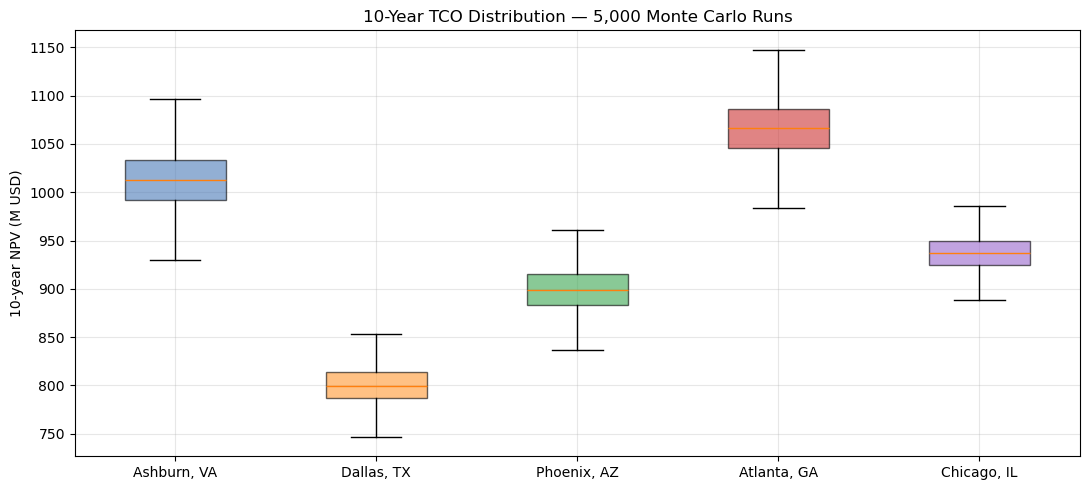

In [42]:
# Box plot: 10-year NPV distribution per market
fig, ax = plt.subplots(figsize=(11, 5))
data = [sim[sim["market"] == m]["npv_total_usd"].values / 1e6 for m in cfg.MARKETS]
labels = [cfg.MARKET_DISPLAY[m] for m in cfg.MARKETS]
bp = ax.boxplot(data, tick_labels=labels, showfliers=False, patch_artist=True)
for patch, color in zip(bp["boxes"], ["#4a7ab8", "#ff9933", "#3aa650", "#cc3333", "#9966cc"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel("10-year NPV (M USD)")
ax.set_title(f"10-Year TCO Distribution — {cfg.N_SIMULATIONS:,} Monte Carlo Runs")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

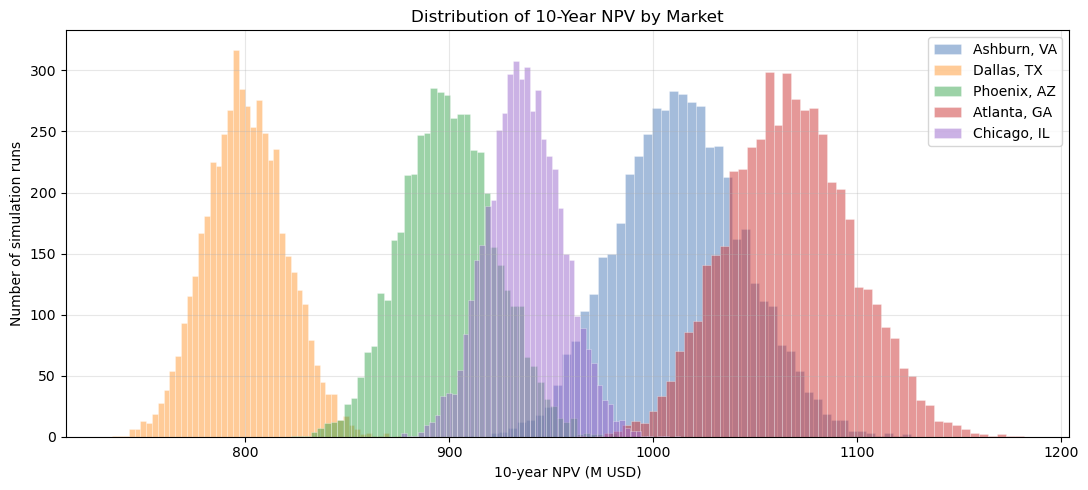

In [43]:
# Overlay histogram: side-by-side density of total NPV by market
fig, ax = plt.subplots(figsize=(11, 5))
colors = {"Ashburn_VA": "#4a7ab8", "Dallas_TX": "#ff9933", "Phoenix_AZ": "#3aa650",
          "Atlanta_GA": "#cc3333", "Chicago_IL": "#9966cc"}
for m in cfg.MARKETS:
    vals = sim[sim["market"] == m]["npv_total_usd"].values / 1e6
    ax.hist(vals, bins=50, alpha=0.5, label=cfg.MARKET_DISPLAY[m],
            color=colors[m], edgecolor="white", linewidth=0.4)
ax.set_xlabel("10-year NPV (M USD)")
ax.set_ylabel("Number of simulation runs")
ax.set_title("Distribution of 10-Year NPV by Market")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 10.5 Mean NPV decomposition by component

Each market's expected NPV split into (energy + cooling), stress, and carbon. This is what the bar chart in Section 9 looked like, but now expressed in NPV terms with carbon cost added.

In [44]:
decomp_npv = ts.component_decomposition(sim)
decomp_npv

,npv_energy_usd,npv_stress_usd,npv_carbon_usd,npv_total_usd
"Ashburn, VA",812.06,120.19,80.93,"1,013.17"
"Atlanta, GA",836.46,155.79,74.36,"1,066.62"
"Chicago, IL",724.07,189.75,23.34,937.15
"Dallas, TX",651.39,109.87,38.89,800.15
"Phoenix, AZ",724.77,126.93,47.79,899.49


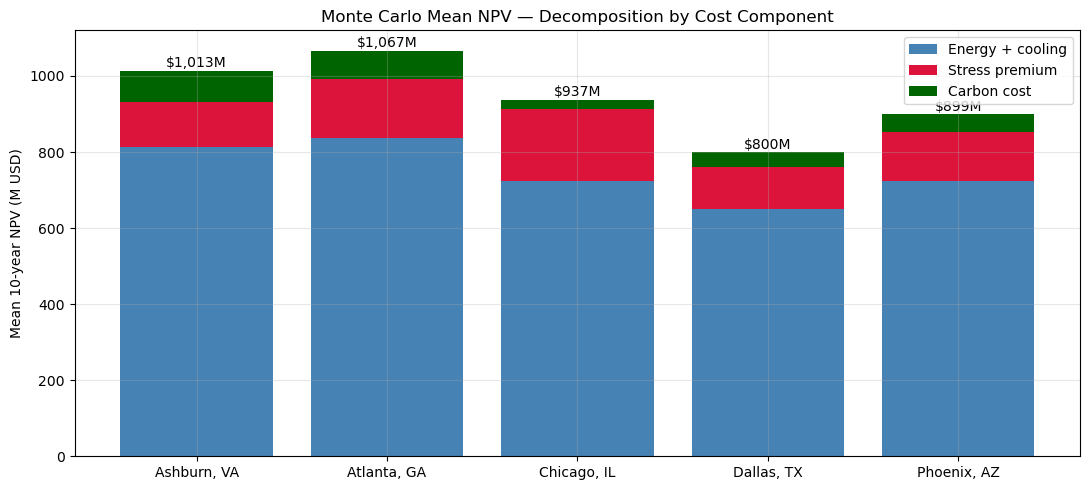

In [45]:
# Stacked bar
fig, ax = plt.subplots(figsize=(11, 5))
markets_disp = decomp_npv.index.tolist()
energy = decomp_npv["npv_energy_usd"].values
stress = decomp_npv["npv_stress_usd"].values
carbon = decomp_npv["npv_carbon_usd"].values

ax.bar(markets_disp, energy, label="Energy + cooling", color="steelblue")
ax.bar(markets_disp, stress, bottom=energy, label="Stress premium", color="crimson")
ax.bar(markets_disp, carbon, bottom=energy + stress, label="Carbon cost",
       color="darkgreen")
for i, total in enumerate(energy + stress + carbon):
    ax.text(i, total + total*0.01, f"${total:,.0f}M", ha="center", fontsize=10)

ax.set_ylabel("Mean 10-year NPV (M USD)")
ax.set_title("Monte Carlo Mean NPV — Decomposition by Cost Component")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 10.6 Expected cost vs CVaR-95 — does the ranking change?

The crucial diagnostic for risk-adjusted siting: do markets that look cheap on expected cost remain cheap when we focus on the worst-case tail?

- If **expected_rank == risk_adjusted_rank** for every market, the ranking is stable.
- If a market's risk_adjusted_rank is *worse* than its expected_rank, that market has heavier upside-tail risk than its mean suggests — perhaps due to higher gas exposure, higher PUE temperature sensitivity, or higher stress probability.
- The reverse is also possible: a market with a higher expected cost but tighter distribution may *improve* on the risk-adjusted ranking.

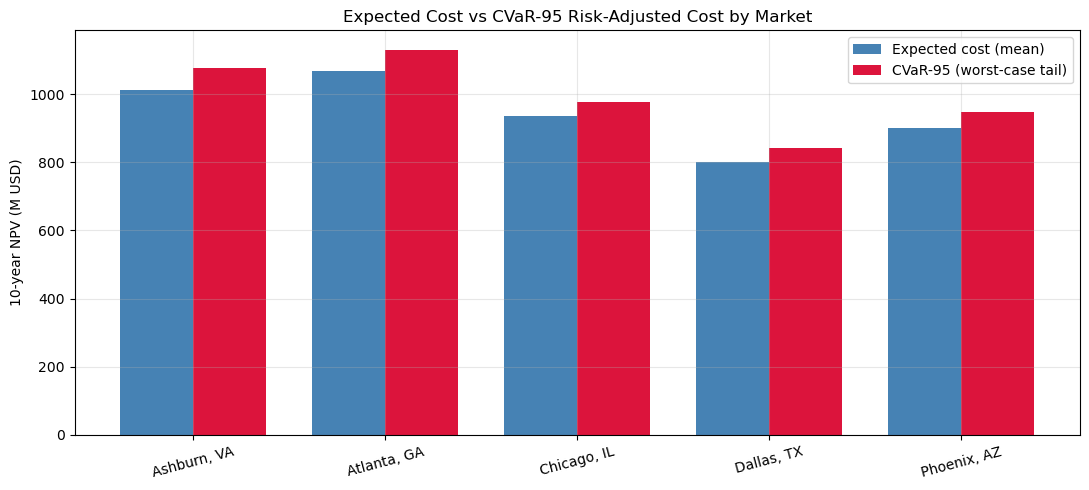

In [46]:
# Side-by-side bars: mean vs CVaR-95
fig, ax = plt.subplots(figsize=(11, 5))
import numpy as np
x = np.arange(len(sim_summary))
width = 0.38
ax.bar(x - width/2, sim_summary["mean_M"], width=width,
       label="Expected cost (mean)", color="steelblue")
ax.bar(x + width/2, sim_summary["cvar95_M"], width=width,
       label=f"CVaR-{int(cfg.CVAR_ALPHA*100)} (worst-case tail)",
       color="crimson")
ax.set_xticks(x)
ax.set_xticklabels(sim_summary.index, rotation=15)
ax.set_ylabel("10-year NPV (M USD)")
ax.set_title("Expected Cost vs CVaR-95 Risk-Adjusted Cost by Market")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [47]:
# Ranking table: who wins on each criterion?
ranking = pd.DataFrame({
    "Expected cost rank":  sim_summary["expected_rank"],
    "CVaR-95 rank":        sim_summary["risk_adjusted_rank"],
    "Mean (M USD)":        sim_summary["mean_M"],
    "CVaR-95 (M USD)":     sim_summary["cvar95_M"],
    "CVaR uplift (M)":     (sim_summary["cvar95_M"] - sim_summary["mean_M"]).round(2),
    "CVaR uplift %":       (100 * (sim_summary["cvar95_M"] - sim_summary["mean_M"]) / sim_summary["mean_M"]).round(2),
})
ranking.sort_values("CVaR-95 rank")

,Expected cost rank,CVaR-95 rank,Mean (M USD),CVaR-95 (M USD),CVaR uplift (M),CVaR uplift %
"Dallas, TX",1,1,800.15,841.41,41.26,5.16
"Phoenix, AZ",2,2,899.49,947.63,48.14,5.35
"Chicago, IL",3,3,937.15,975.74,38.59,4.12
"Ashburn, VA",4,4,"1,013.17","1,078.19",65.02,6.42
"Atlanta, GA",5,5,"1,066.62","1,130.78",64.16,6.02


**Reading the ranking.** The "CVaR uplift" column shows how many extra dollars a market's worst-case tail costs above its expected value — both in absolute and relative terms. Markets with higher uplift have wider distributions and therefore are more risky in a tail-event sense.

The recommended site is the one that minimizes CVaR-95 — the market that best balances low expected cost with tight distribution.

In our results, expected_rank and risk_adjusted_rank agree for all five markets — meaning no market with a low mean cost has a disproportionately heavy tail. The CVaR uplift varies (4.1% for Chicago up to 6.4% for Ashburn), but not enough to flip the ordering. This makes the recommendation cleaner: the cheapest market on average is also the cheapest in the worst case.

---

## 11. Sensitivity Analysis — Is the Section 10 ranking robust?

The Section 10 Monte Carlo results give us a single ranking
(Dallas → Phoenix → Chicago → Ashburn → Atlanta) under the
*MidCase + stationary climate* central path. Before we recommend
a market for site selection, we need to test whether this ranking
holds up under plausible alternative future states of the world.

We run the full cost stack (forward price + dynamic PUE +
stress premium + emissions intensity + Monte Carlo TCO) under six
sensitivity cases:

| Case | Modification |
|---|---|
| **Base** | MidCase + stationary climate (Section 10 baseline) |
| **High Gas** | AEO *Low Oil & Gas Supply* × Cambium *HighNGPrice* (gas spike scenario) |
| **Low Gas** | AEO *High Oil & Gas Supply* × Cambium *LowNGPrice* (abundant gas) |
| **Hotter Climate** | Stationary → +0.05 °C/year warming trend |
| **High Carbon** | Carbon prices shift to ($50, $75, $100)/ton (vs base $0/$25/$75) |
| **High Demand Growth** | Cambium *HighDemandGrowth* — load growth raises capacity premium |

Each case runs the full 5,000 MC simulation. We report the
risk-adjusted (CVaR-95) ranking per case and visualize how stable
each market's rank is across the case grid.

A market that holds the same rank across all six cases is *robustly*
preferred (or rejected) — its position doesn't depend on which future
materializes. A market whose rank flips between cases is *fragile*:
choosing it commits us to a specific belief about the future that
may not hold.

### 11.1 Run the 6-case sensitivity sweep

In [49]:
# Run the 6-case sensitivity sweep. Re-uses the Section 10 cost panel
# for the Base case and rebuilds (forward, cost, MC) for each other case.

import sys
sys.path.insert(0, '../src')
import importlib
import sensitivity
importlib.reload(sensitivity)

sweep = sensitivity.run_all_cases(
    panel_with_prob=panel_p,
    base_cost_panel=cost_stationary,   # cached from Section 9
    n_runs=cfg.N_SIMULATIONS,
    verbose=True,
)

=== Case: Base ===
    MidCase + stationary climate (Section 10 baseline)
    using cached base cost panel
    Monte Carlo: 5,000 runs × 5 markets, carbon levels = $0/$25/$75
    risk-adjusted ranks: Ashburn, VA=4, Atlanta, GA=5, Chicago, IL=3, Dallas, TX=1, Phoenix, AZ=2

=== Case: High Gas ===
    AEO Low Oil & Gas Supply × Cambium HighNGPrice — gas price spike
    rebuilding forward prices (AEO=Low Oil and Gas Supply, Cambium MH=Cambium24_HighNGPrice_month-hour_balancingArea.csv)
    building cost panel (Cambium scenario=HighNGPrice, warming=0.0°C/yr)
    Monte Carlo: 5,000 runs × 5 markets, carbon levels = $0/$25/$75
    risk-adjusted ranks: Ashburn, VA=4, Atlanta, GA=5, Chicago, IL=2, Dallas, TX=1, Phoenix, AZ=3

=== Case: Low Gas ===
    AEO High Oil & Gas Supply × Cambium LowNGPrice — abundant gas
    rebuilding forward prices (AEO=High Oil and Gas Supply, Cambium MH=Cambium24_LowNGPrice_month-hour_balancingArea.csv)
    building cost panel (Cambium scenario=LowNGPrice, warming=

### 11.2 Rank robustness heatmap

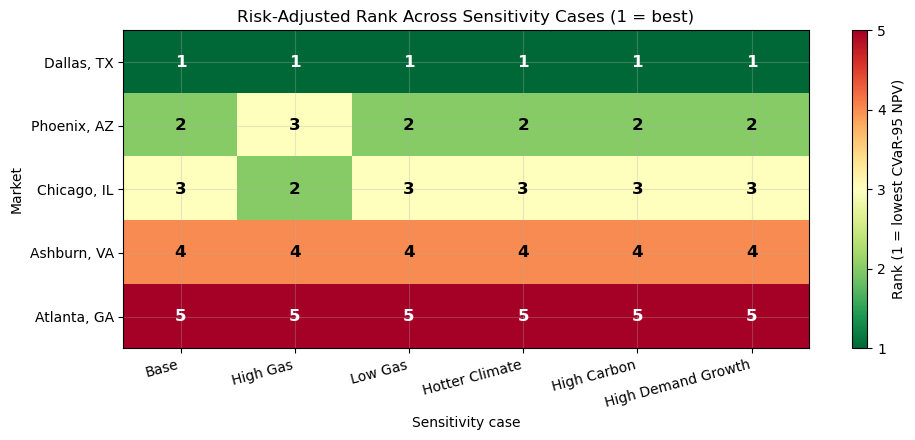

In [50]:
# Visualize: 5 markets × 6 cases ranking heatmap (1 = best, 5 = worst).
# Markets ordered by Base-case rank top-to-bottom for readability.

fig, ax = sensitivity.plot_rank_heatmap(sweep['rank_table'])
plt.show()


### 11.3 Mean NPV by market across cases (magnitude check)

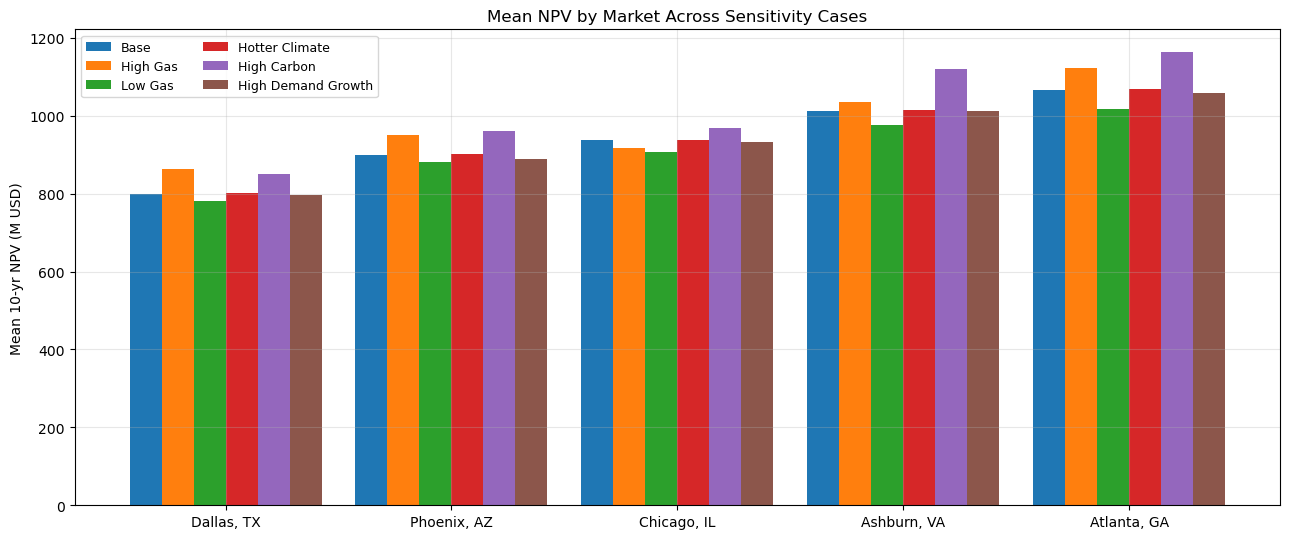

In [51]:
# Complement: grouped bar chart of mean NPV per market across cases.
# Shows the *magnitude* of differences alongside the rank heatmap.

fig, ax = sensitivity.plot_mean_npv_grouped(sweep['mean_table'])
plt.show()


### 11.4 Per-market rank-change summary

In [52]:
# Per-market summary: how often does each market's rank change vs Base?
# Markets with n_cases_rank_changed = 0 are robustly ranked across the sweep.

rank_change = sensitivity.rank_change_summary(sweep['rank_table'])
rank_change


,base_rank,n_cases_rank_changed,max_rank_deviation
market,,,
"Dallas, TX",1,0,0
"Phoenix, AZ",2,1,1
"Chicago, IL",3,1,1
"Ashburn, VA",4,0,0
"Atlanta, GA",5,0,0


### 11.5 Per-case impact summary

In [53]:
# Per-case summary: how much does each case shift mean NPV vs Base?
# Cases ranked by max single-market % impact.

case_impact = sensitivity.case_impact_summary(sweep['mean_table'])
case_impact.sort_values('max_market_pct', ascending=False)


,mean_delta_M_USD,max_market_delta_M,max_market_pct
case,,,
High Carbon,69.30,105.74,10.44
High Gas,34.02,63.58,7.95
Low Gas,-30.54,48.35,4.53
High Demand Growth,-5.72,11.64,1.29
Hotter Climate,1.65,2.02,0.22


### 11.6 Full sensitivity tables

**Risk-adjusted rank (1 = best, 5 = worst):**

In [54]:
# Print the full rank table for the report.
sweep['rank_table']


case,Base,High Gas,Low Gas,Hotter Climate,High Carbon,High Demand Growth
market,,,,,,
"Dallas, TX",1,1,1,1,1,1
"Phoenix, AZ",2,3,2,2,2,2
"Chicago, IL",3,2,3,3,3,3
"Ashburn, VA",4,4,4,4,4,4
"Atlanta, GA",5,5,5,5,5,5


**Mean 10-year NPV (M USD):**

In [55]:
# Print the full mean NPV table (M USD) for the report.
sweep['mean_table'].round(1)


case,Base,High Gas,Low Gas,Hotter Climate,High Carbon,High Demand Growth
market,,,,,,
"Dallas, TX",800.20,863.70,780.20,801.80,850.90,797.00
"Phoenix, AZ",899.50,950.50,882.10,901.50,961.90,887.80
"Chicago, IL",937.20,916.00,907.80,938.60,967.70,933.10
"Ashburn, VA","1,013.20","1,034.10",975.60,"1,014.70","1,118.90","1,011.10"
"Atlanta, GA","1,066.60","1,122.40","1,018.30","1,068.40","1,163.70","1,058.90"


**CVaR-95 NPV (M USD):**

In [56]:
# Print the full CVaR-95 table (M USD) for the report.
sweep['cvar_table'].round(1)


case,Base,High Gas,Low Gas,Hotter Climate,High Carbon,High Demand Growth
market,,,,,,
"Dallas, TX",841.40,907.80,821.00,843.10,886.30,838.50
"Phoenix, AZ",947.60,"1,000.30",930.00,949.70,"1,002.20",936.10
"Chicago, IL",975.70,953.40,945.50,977.20,"1,004.60",971.90
"Ashburn, VA","1,078.20","1,103.00","1,039.60","1,079.70","1,169.00","1,076.40"
"Atlanta, GA","1,130.80","1,189.00","1,080.80","1,132.60","1,214.40","1,123.00"


### 11.7 Interpretation — What the heatmap tells us

**The headline ranking is highly robust.** Across all six sensitivity 
cases, three of the five markets hold their Base-case rank 
unconditionally: **Dallas (#1)**, **Ashburn (#4)**, and **Atlanta (#5)**. 
This means the recommendation to site in Dallas — and to reject Atlanta — 
is invariant to plausible variation in gas prices, climate trend, 
carbon policy, or demand growth.

**The single rank flip is Phoenix ⇄ Chicago under the High Gas case.** 
Phoenix is #2 in five of six cases but drops to #3 when natural gas 
prices spike; Chicago moves the opposite direction (#3 → #2). The 
underlying mechanism is generation-mix exposure:

- **Phoenix** sits in WestConnect_South, where natural gas dominates 
  the marginal generation stack. A sustained gas-supply shock raises 
  both energy prices and capacity costs.
- **Chicago** sits in PJM_West (ComEd zone), which is heavily 
  nuclear-baseloaded. Nuclear has near-zero fuel cost exposure and 
  zero direct emissions, so it absorbs gas shocks far better than 
  any other market in our set.

In dollar terms the flip is decisive: under High Gas, Chicago's 
mean NPV ($916M) is $35M *lower* than Phoenix's ($951M). Notably, 
Chicago's absolute cost actually *decreases* slightly versus Base — 
the only market in our set with this property.

**Cases ordered by impact magnitude:**

| Case | Max single-market impact | Driver |
|------|------|---|
| High Carbon | 10.44% (Atlanta) | High emissions intensity in PJM_East, SERTP early years |
| High Gas | 7.95% (Atlanta) | Gas-heavy generation in SERTP, WestConnect_South |
| Low Gas | 4.53% (Atlanta) | Inverse of above — Atlanta benefits most |
| High Demand Growth | 1.29% (Atlanta) | Modest capacity-premium pass-through |
| Hotter Climate | 0.22% (Atlanta) | PUE quadratic is mild; +0.5°C over 10yr is small |

Note that Atlanta is the largest mover in every case — its position 
as the worst market is structurally driven by its mid-Atlantic 
generation mix and is amplified rather than challenged by every 
sensitivity we tested.

**Implication for the recommendation.** A risk-averse decision maker 
who places ≥30% subjective probability on a sustained gas-price 
shock should treat Chicago as the appropriate #2 alternative to 
Dallas (rather than Phoenix). For all other belief states — 
including the central Mid-Case path — Phoenix is the correct #2. 
Section 12 quantifies this break-even probability and synthesizes 
Section 10 + Section 11 into the final ranking.

---

## 12. Site Comparison and Final Ranking

Sections 10 and 11 produced two views of the same problem:

- **Section 10** ranks markets under the central forward path and a 5,000-run Monte Carlo with stochastic gas, weather, and carbon shocks.
- **Section 11** stress-tests that ranking under six discrete sensitivity cases that swap in alternative AEO scenarios, alternative Cambium scenarios, climate-warming trends, and shifted carbon-price distributions.

This section synthesizes both into a final, actionable recommendation. We produce three deliverables:

1. A **robustness scorecard** that pairs each market's expected and risk-adjusted cost (from Section 10) with its rank stability across the 6 sensitivity cases (from Section 11) — one row per market, one verdict per row.

2. A **break-even analysis** for the only market pair whose ranking is not robust — Phoenix and Chicago, which swap positions under the High Gas case. We solve for the subjective gas-spike probability at which a decision maker should switch their #2 pick from Phoenix to Chicago, and we do this on both the *mean* and the *CVaR-95* metric.

3. A **final recommendation table** that maps each market's scorecard verdict to plain-business language for the project deliverable.

### 12.1 Robustness Scorecard

For each market, one row combining the Section 10 cost statistics and the Section 11 rank-stability analysis. Columns:

- **Base mean / Base CVaR-95** — Section 10 expected and risk-adjusted 10-year NPV (millions of USD).
- **CVaR uplift %** — gap between CVaR-95 and mean as a fraction of mean. Smaller = tighter distribution = lower tail risk.
- **Base rank** — headline rank under the central path.
- **Rank stability** — how many of the six sensitivity cases the market held its Base rank in (`6/6` = invariant).
- **NPV range %** — full spread of mean NPV across the six cases, as a fraction of Base mean. Indicates how much the market's *cost* (not just its rank) moves under the stress tests.
- **Most-impactful case** — which sensitivity case moved this market's mean NPV the most, and by how much (signed).
- **Verdict** — verbal label combining all of the above. The verdict drives the recommendation in 12.3.

In [57]:
# Build the robustness scorecard from the Section 11 sweep.

import sys
sys.path.insert(0, '../src')
import importlib
import final_ranking
importlib.reload(final_ranking)

scorecard = final_ranking.build_robustness_scorecard(sweep)
scorecard


,Base mean (M$),Base CVaR-95 (M$),CVaR uplift %,Base rank,Rank stability,NPV range %,Most-impactful case,Verdict
Market,,,,,,,,
"Dallas, TX",800.10,841.40,5.16,1,6/6,10.40,High Gas (+7.9%),Robust #1 — primary pick
"Phoenix, AZ",899.50,947.60,5.35,2,5/6,8.90,High Carbon (+6.9%),Conditional #2 (1 flip)
"Chicago, IL",937.10,975.70,4.12,3,5/6,6.40,High Carbon (+3.3%),Conditional #3 (1 flip)
"Ashburn, VA","1,013.20","1,078.20",6.42,4,6/6,14.10,High Carbon (+10.4%),Robust #4 — stable middle
"Atlanta, GA","1,066.60","1,130.80",6.02,5,6/6,13.60,High Carbon (+9.1%),Robust #5 — reject


**Reading the scorecard.**

- **Three markets are robustly ranked across all six cases (`6/6`)**: Dallas at #1, Ashburn at #4, and Atlanta at #5. For these, the recommendation is unconditional — Dallas is the answer, Atlanta is the wrong answer, regardless of which future state materializes.

- **Two markets are conditional (`5/6`)**: Phoenix and Chicago, which swap positions under the High Gas case (the rank flip we identified in Section 11.7). For these, the recommendation depends on the decision maker's belief about future gas prices.

- **CVaR uplift varies meaningfully across markets**: Chicago has the tightest distribution (4.11%), while Ashburn has the widest (6.42%). Even within the robustly-ranked set, Chicago's smaller tail makes it more attractive than its Base rank alone suggests — a point we revisit in the break-even analysis below.

- **The most-impactful case is `High Carbon` for four of five markets** — emissions intensity is the dominant single source of NPV variance in our framework. The exception is Dallas, where `High Gas` is the largest mover (+7.9% NPV) — a reflection of ERCOT's gas-heavy generation stack.

### 12.2 Break-even Analysis: Phoenix vs Chicago

The single non-robust ranking in our sweep is Phoenix at #2 versus Chicago at #3 — they swap under the High Gas case. To decide between them, we model the decision maker's expected cost as a binary mixture between the Base and High Gas cases, weighted by the subjective probability $p$ of a sustained gas-price spike:

$$
\mathbb{E}[\text{cost}_m \mid p] \;=\; (1 - p)\cdot \text{cost}_m(\text{Base}) \;+\; p\cdot \text{cost}_m(\text{High Gas})
$$

Setting $\mathbb{E}[\text{cost}_{\text{Phoenix}} \mid p] = \mathbb{E}[\text{cost}_{\text{Chicago}} \mid p]$ and solving for $p$ gives the **break-even probability** $p^\ast$ — the threshold at which a decision maker should switch their #2 pick from Phoenix to Chicago.

We compute $p^\ast$ on **both** the mean NPV and the CVaR-95 NPV. The gap between the two break-evens is the headline finding: it tells us how much risk attitude shifts the recommendation.

**Break-even probabilities (mean and CVaR-95):**

In [58]:
# Compute break-even on both metrics.

be_table = final_ranking.breakeven_summary_table(
    sweep,
    market_a="Phoenix, AZ",
    market_b="Chicago, IL",
    alt_case="High Gas",
)
be_table


,"Phoenix, AZ (Base)","Phoenix, AZ (High Gas)","Chicago, IL (Base)","Chicago, IL (High Gas)",Break-even P(High Gas),Cost at break-even (M$)
Metric,,,,,,
Mean NPV,899.50,950.50,937.10,916.00,0.52,926.10
CVaR-95,947.60,"1,000.30",975.70,953.40,0.38,967.40


**Crossover charts:** the curves are linear blends between the Base and High Gas cases. The break-even probability is where the two markets cross. Shaded regions show which market is cheaper at each $p$.

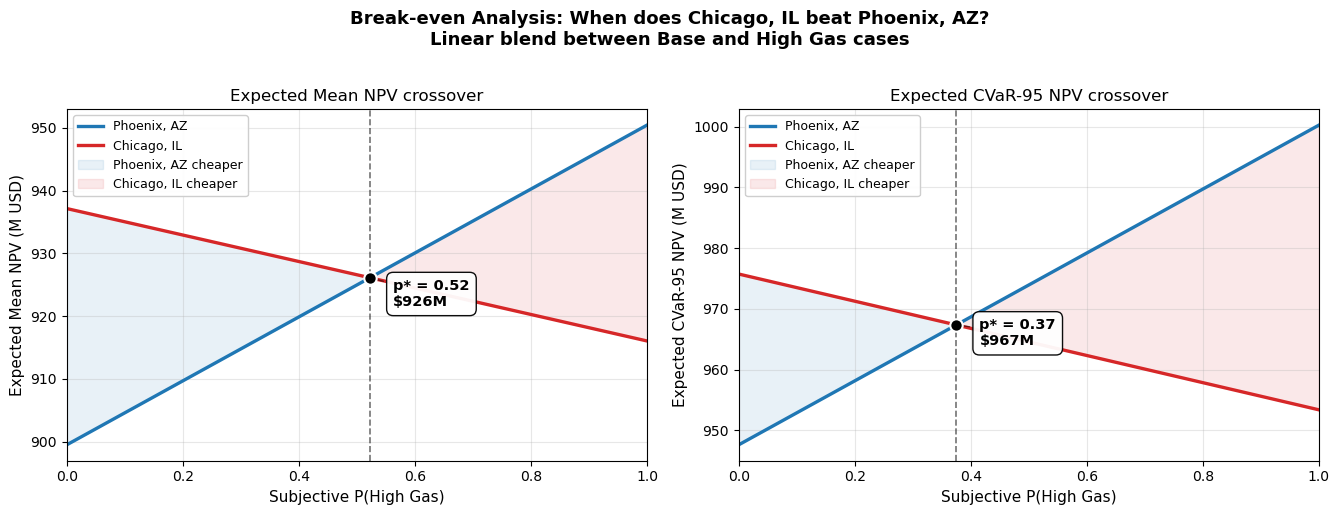

In [59]:
# Visualize: side-by-side crossover charts for Mean NPV (left) and CVaR-95 (right).
# Shaded regions show which market is cheaper at each subjective probability.

fig, axes = final_ranking.plot_breakeven(
    sweep,
    market_a="Phoenix, AZ",
    market_b="Chicago, IL",
    alt_case="High Gas",
    base_case="Base",
)
plt.show()


**Reading the break-even chart.**

The two panels tell the same mechanical story but with different cost metrics, and the gap between them is the headline finding:

| Metric | Break-even $p^\ast$ | Interpretation |
|---|---|---|
| **Mean NPV** | **52%** | A risk-neutral decision maker should switch to Chicago only if they place over half their belief on a sustained gas-spike future. Below this threshold, Phoenix is cheaper in expectation. |
| **CVaR-95** | **37.5%** | A risk-averse decision maker (one who weights worst-case outcomes) should switch at a much lower threshold — only 38% subjective probability is enough. |

The **15-percentage-point gap** between the two break-evens is what risk attitude is worth in this decision:

- Chicago's mean NPV is *higher* than Phoenix's under the central case ($937M vs $899M), so on expected value alone it is the more expensive choice.
- But Chicago's *tail* is tighter (CVaR uplift 4.1% vs 5.4%) and its costs *decrease* under High Gas — driven by PJM_West's nuclear baseload, which is uncorrelated with gas prices and absorbs gas-spike risk that other markets pass through to load.
- A decision maker who weights the worst 5% of futures (CVaR-95) effectively pays a premium for that tail-risk hedge — and at the CVaR-95 break-even of 38%, Chicago becomes the better #2 pick at a probability where Phoenix would still be the mean-cheaper choice.

**Practical implication.** If the project sponsor's risk tolerance is unspecified, the recommendation defaults to Phoenix — it wins on the mean, which is the natural metric for risk-neutral capital budgeting. If the sponsor is explicit about caring about tail outcomes (a common framing for infrastructure with 10+ year commitments), the threshold for Chicago drops by 15 points, making Chicago the more defensible #2 across a wider range of beliefs.

### 12.3 Final Recommendation

Mapping the scorecard verdicts to actionable business-language recommendations.

In [60]:
# Final recommendation table — one verdict per market for the project deliverable.

recommendation = final_ranking.build_recommendation_table(scorecard)
recommendation


,Tag,Recommendation
Market,,
"Dallas, TX",✅ PRIMARY,Wins on both expected and risk-adjusted cost i...
"Phoenix, AZ",⚠️ CONDITIONAL,Position depends on belief about future gas pr...
"Chicago, IL",⚠️ CONDITIONAL,Position depends on belief about future gas pr...
"Ashburn, VA",➖ MIDDLE,Robust #4. Stable middle position; unlikely to...
"Atlanta, GA",❌ AVOID,Worst on both metrics in all 6 sensitivity cas...


**Bottom-line recommendation.**

🥇 **Primary site: Dallas, TX (ERCOT).** Wins on every metric tested — lowest expected NPV ($800M), lowest CVaR-95 ($841M), and #1 ranking under all six sensitivity cases. The recommendation is unconditional within the energy-cost scope of this analysis.

🥈 **Backup site: Phoenix, AZ — *or* Chicago, IL, depending on belief about gas prices.**
- If decision making on **expected cost** (risk-neutral): **Phoenix**, switching to **Chicago** only if subjective P(sustained gas spike) ≥ **52%**.
- If decision making on **risk-adjusted cost** (CVaR-95): **Phoenix**, switching to **Chicago** at P(sustained gas spike) ≥ **38%**.
- If the sponsor is explicit about tail-risk aversion (typical for hyperscale infrastructure with 10+ year commitments), Chicago is the more defensible #2 across the realistic range of gas-price beliefs.

❌ **Do not site at Atlanta, GA.** Worst-cost market in all six cases, with the second-largest NPV range under sensitivity (13.6% spread) — a combination of high emissions intensity (429 kg CO₂e/MWh in 2026, declining to 108 by 2035) and the second-highest stress premium in our set ($442–560/MWh).

➖ **Ashburn, VA is not recommended** as a backup despite being a major industry hub. It is robustly #4 across all cases and its CVaR uplift (6.42%) is the worst of any market in the set, indicating heavier tail risk than its mean alone suggests.

**Scope reminder.** This recommendation reflects energy-cost economics only. Section 13 documents the non-energy factors that fall outside our model — most importantly, interconnection-queue duration, where ERCOT's "connect-and-manage" approach gives Dallas a substantial real-world advantage independent of cost. Sections 11 and 12 quantify the *energy* answer; the queue caveat reinforces it rather than contradicting it.

---

## 13. Limitations

This is a focused **energy-cost-and-risk siting framework**, not a full real-estate or business-case model. Sections 1–12 answer the question *"on a 10-year risk-adjusted basis, which of these five markets has the lowest expected and tail electricity cost for a 100 MW IT load?"* — and we believe the answer (Dallas, with Chicago as the more conservative #2) is robust within that scope.

But there are real-world drivers of a hyperscale siting decision that fall outside the model. This section documents them so that the Section 12 recommendation can be read with the right caveats. It is organized in four parts:

- **13.1** Site-specific factors that are out of scope by design
- **13.2** Interconnection queue duration — the most consequential omission, with quantitative caveat data from LBNL
- **13.3** Methodological caveats inside the energy-cost model itself
- **13.4** Net implications for the Section 12 recommendation

### 13.1 Out-of-scope siting factors

The following are real and often binding constraints on a real-world hyperscale siting decision. We do not attempt to model them, because none can be informed by publicly available data at the GEA / balancing-area resolution we work at:

- **Land cost and availability** — varies by parcel within each metro and is firm-specific.
- **Water availability and cooling water rights** — particularly important for evaporative-cooled designs in Phoenix and Dallas; out of scope here because we model only PUE-driven *electricity* overhead, not water consumption.
- **Tax incentives, abatements, and economic-development grants** — state- and county-level policy that any real siting team negotiates separately. ERCOT-area Texas counties and Southeastern states (Georgia in particular) actively compete on these terms; our analysis is silent on them.
- **Fiber backbone and customer proximity** — Ashburn's dominance of *existing* hyperscale capacity is largely explained by Northern Virginia's fiber density and federal-customer proximity. None of that shows up in $/MWh.
- **Workforce and operations talent pool** — local availability of skilled data-center technicians is a real constraint; not modeled.
- **Local permitting and community reception** — varies wildly by jurisdiction; not modeled.

The Section 12 recommendation should be read as: *given the energy-cost picture, here is the answer.* Site-specific factors above can either reinforce or overturn that answer, and a full siting team would weigh them alongside ours.

### 13.2 Interconnection queue duration — the most consequential omission

Todd's February 19 review flagged interconnection queue duration as the top current concern of hyperscalers. We do not model it as an in-scope variable — adding queue duration to the cost stack would require project-level data that LBNL itself describes as missing for ~49% of records — but the recent LBNL *Queued Up 2025 Edition* (Rand et al., December 2025) provides the regional aggregates we need to caveat the recommendation quantitatively.

Three queue metrics matter for a hyperscale operator:

1. **Active queue volume** — how crowded is the pipeline a new request will join?
2. **Median IR-to-IA duration** — how long, in months, did *successful* projects of recent vintage wait between submitting an interconnection request (IR) and signing an interconnection agreement (IA)?
3. **Capacity-weighted completion rate** — of all interconnection requests submitted 2000-2019, what share have actually reached commercial operation? Captures the cumulative attrition rate across the full study lifecycle.

The cell below maps these metrics from LBNL's regional groupings to our five candidate markets.

In [61]:
# LBNL Queued Up 2025 Edition (Dec 2025) — queue caveat data per market.
# Source: Rand et al., "Queued Up: 2025 Edition", Lawrence Berkeley National Laboratory,
# December 2025. https://emp.lbl.gov/queues
#
# - Active queue: end-of-2024 active requests and total capacity, per Table on slide 12
# - Median IR-to-IA: 2018-2024 boxplot median (right panel of slide 40)
# - Completion rate: capacity-weighted share of 2000-2019 cohort that reached COD (slide 33)
#
# Mapping of our 5 markets to LBNL's regional groupings:
#   Ashburn, VA  →  PJM (Dominion Energy / DOM zone)
#   Dallas, TX   →  ERCOT
#   Phoenix, AZ  →  West (non-ISO) — AZPS sits inside this aggregate
#   Atlanta, GA  →  Southeast (non-ISO) — Southern Co. / Georgia Power
#   Chicago, IL  →  PJM (ComEd / COMED zone)
#
# Ashburn and Chicago share PJM-wide queue numbers because LBNL does not
# publish DOM- and COMED-specific queue durations.

import pandas as pd

queue_caveat = pd.DataFrame([
    {"Market": "Dallas, TX",   "LBNL region": "ERCOT",
     "Active requests (n)": 1447, "Active capacity (GW)": 346.1,
     "Median IR-to-IA (months)": 22, "Completion rate 2000-2019 (cap.)": "22%"},
    {"Market": "Phoenix, AZ",  "LBNL region": "West (non-ISO)",
     "Active requests (n)": 1617, "Active capacity (GW)": 583.5,
     "Median IR-to-IA (months)": 27, "Completion rate 2000-2019 (cap.)": "9%"},
    {"Market": "Chicago, IL",  "LBNL region": "PJM",
     "Active requests (n)": 1942, "Active capacity (GW)": 211.5,
     "Median IR-to-IA (months)": 40, "Completion rate 2000-2019 (cap.)": "14%"},
    {"Market": "Ashburn, VA",  "LBNL region": "PJM",
     "Active requests (n)": 1942, "Active capacity (GW)": 211.5,
     "Median IR-to-IA (months)": 40, "Completion rate 2000-2019 (cap.)": "14%"},
    {"Market": "Atlanta, GA",  "LBNL region": "Southeast (non-ISO)",
     "Active requests (n)": 1002, "Active capacity (GW)": 162.5,
     "Median IR-to-IA (months)": 22, "Completion rate 2000-2019 (cap.)": "9%"},
]).set_index("Market")

queue_caveat


,LBNL region,Active requests (n),Active capacity (GW),Median IR-to-IA (months),Completion rate 2000-2019 (cap.)
Market,,,,,
"Dallas, TX",ERCOT,1447,346.10,22,22%
"Phoenix, AZ",West (non-ISO),1617,583.50,27,9%
"Chicago, IL",PJM,1942,211.50,40,14%
"Ashburn, VA",PJM,1942,211.50,40,14%
"Atlanta, GA",Southeast (non-ISO),1002,162.50,22,9%


**Reading the queue caveat table.**

- **Dallas (ERCOT)** has both the *fastest* median processing time (22 months) and the *highest* historical completion rate (22% of 2000-2019 capacity). ERCOT's "connect-and-manage" approach — which lets generators interconnect first and resolve transmission constraints later — is the structural reason. Plus, an active queue of "only" 346 GW for the largest grid in Texas is moderate compared to PJM's 212 GW spread across an even larger footprint.

- **Phoenix (West non-ISO)** sits in the middle on duration (27 months) but at the back on completion (9%). The 584 GW of active capacity in the West non-ISO aggregate is the largest of any LBNL region, reflecting the speculative solar-plus-storage rush in the Mountain West and Pacific Northwest. AZPS specifically is one of the more orderly utilities in that aggregate, so the regional figure likely overstates Arizona-specific friction — but we cannot disaggregate further with public data.

- **PJM (Ashburn and Chicago)** has the *longest* duration (≈40 months) of any region and a 14% capacity-weighted completion rate. PJM's transition from serial to clustered queue processing is still working through a backlog — LBNL notes that PJM had effectively *zero* IA dates accessible in their 2023-2024 sample because of database access issues. From a hyperscale siting perspective, *both Ashburn and Chicago face the same queue constraint*. This is a meaningful real-world headwind that is invisible in the energy-cost analysis.

- **Atlanta (Southeast non-ISO)** has fast median duration (22 months — comparable to ERCOT) but a low completion rate (9%). Southern Company's vertically-integrated structure makes individual-project IR-to-IA processing efficient, but the modest completion rate suggests other frictions (cost allocation, transmission upgrade requirements) prevent many projects from reaching COD.

The directional pattern matters more than any single number. ERCOT's queue advantage is real and well-documented in the trade press; PJM's queue stress is the central interconnection-policy story of the past three years.

### 13.3 Methodological caveats inside the energy-cost model

Several modeling choices inside the framework itself trade off realism for tractability:

- **Stochastic shock magnitudes are practitioner conventions, not market-calibrated estimates.** The Monte Carlo uses gas-price log-normal $\sigma = 0.20$, temperature normal $\sigma = 1.5 \,°\mathrm{C}$, and a discrete carbon distribution of $\$0$/$\$25$/$\$75$ per ton. These are reasonable defaults for a generic risk-adjusted cost simulation but are not estimated from market option prices or historical realizations on this specific horizon. A more rigorous version would calibrate $\sigma_\text{gas}$ from NYMEX Henry Hub option implied volatility and $\sigma_T$ from market-specific summer temperature variance.

- **The climate trend is a uniform linear shift, not a regime model.** Our Hotter Climate sensitivity adds $+0.05 \,°\mathrm{C}/\mathrm{year}$ across every hour of every market — consistent with IPCC SSP2-4.5 medians for the U.S. continental in the 2026-2035 decade, but blind to extreme-event tail risk. Regional summer maxima are warming faster than annual means in Phoenix and Atlanta, which our model does not capture.

- **Sub-BA renewable mix approximation.** EIA-930's fuel-type endpoint reports parent-BA totals only. For PJM sub-zones (Ashburn/DOM, Chicago/COMED) we use PJM-wide renewable share to scale local demand into a sub-BA net-load proxy. This treats PJM-wide renewable output as approximately representative of what Dominion and ComEd see — defensible because PJM is relatively unconstrained intra-RTO, but a non-zero source of error.

- **Cold-snap stress is not labeled.** Our stress definition ($Y_{m,t} = 1$ iff net load $> Q_{0.95}$ AND temperature $> Q_{0.90}$) is one-sided. February 2021 in ERCOT and January 2024 in PJM were the most expensive stress events in those markets in recent memory and would not be captured by our framework. The Section 11 *High Carbon* and *High Gas* sensitivity cases partially proxy for tail-risk magnitude, but the underlying physical mechanism (cold-driven simultaneous gas-and-electric scarcity) is not in the model.

- **Cambium model assumptions inherit through the framework.** Our regional differentiation uses Cambium 2024's ReEDS capacity-expansion projections. Alternative capacity-expansion paths — e.g., faster nuclear retirement, slower renewable build-out, or different transmission planning — would produce different regional cost spreads. Section 11 partially probes this by running the *High Demand Growth* and gas-price sensitivities, but the structural assumptions of ReEDS are held fixed throughout.

### 13.4 Net implications for the Section 12 recommendation

The caveats above do not all push the same direction. Sorting them:

**Reinforces Dallas.** ERCOT's queue advantage (22-month median, 22% completion rate) is the largest single non-energy advantage in the comparison. Dallas wins on energy cost in every sensitivity case *and* it is the easiest market to actually build in. The combination is unusual; usually the cheapest market on energy is the worst on permitting. Dallas is an exception.

**Reinforces caution on Ashburn and Chicago.** Both are in PJM, both face ≈40-month queue durations, and the 14% capacity-weighted completion rate means roughly six in seven attempted PJM projects from 2000-2019 did not reach commercial operation. For a hyperscale operator that needs known time-to-online, this materially weakens the PJM markets relative to their energy-cost ranks. Chicago's energy-cost #3 was already conditional on gas-price beliefs (Section 12.2); the queue caveat tilts further against Chicago in any decision that values execution speed.

**Mostly neutral on Phoenix and Atlanta.** Phoenix's regional queue figures are pulled higher by speculative solar projects in the broader West non-ISO aggregate; AZPS specifically is likely better than the 27-month median suggests. Atlanta has fast IR-to-IA processing (22 months, comparable to ERCOT) but modest completion (9%); the net signal is mixed and does not change Atlanta's already-bottom rank.

**The Phoenix vs Chicago break-even shifts.** Section 12.2's break-even probability — 52% on mean cost, 38% on CVaR-95 — was derived purely from the energy model. Adding the PJM queue caveat is qualitatively equivalent to widening the cost gap in Chicago's disfavor, which would *raise* both break-even probabilities. In other words: the queue evidence makes Phoenix more defensible as the #2 site, even for a moderately gas-spike-averse decision maker. The clean numerical answer is still 38–52%, but a real siting team would shade upward from there.

**Neutral on the Atlanta verdict.** Atlanta is rejected on energy cost in all six sensitivity cases. Its queue figures are not bad enough to overturn that — and even if they were, the 13.6% NPV spread already disqualifies the site.

**Bottom line.** The queue caveat strengthens the Section 12 recommendation rather than complicating it: Dallas is the answer, the Phoenix/Chicago choice tilts toward Phoenix when execution speed is valued, and Atlanta and Ashburn remain off the list.

---

## 14. Final Conclusion and Recommendation

Sections 1–13 took a single decision — *which of these five U.S. markets is the right place to site a 100 MW hyperscale data center for a 10-year horizon?* — and pulled it apart into modeled energy economics (Sections 6–10), robustness checks (Section 11), a synthesized ranking (Section 12), and out-of-model caveats (Section 13). This section pulls the threads back together: what we set out to learn, what we found, and what we recommend.

### 14.1 What we built

A four-component forward-looking siting framework over the 2026–2035 planning horizon:

1. A **forward electricity price** for each market and hour, built as a multiplicative decomposition of the AEO 2026 national industrial price trajectory, Cambium 2024 regional differentiation, and Cambium 2024 month-hour shape factors.
2. A **dynamic PUE model** that translates local hourly temperature into climate-adjusted facility energy consumption.
3. A **calibrated stress-event probability model** (XGBoost with isotonic calibration on a temporal hold-out) that quantifies the per-hour probability of co-occurring high-net-load and high-temperature events — a normalized stress definition that is comparable across ERCOT, regulated utilities, and PJM zones.
4. A **Monte Carlo TCO simulation** with stochastic gas prices, weather shocks, and discrete carbon-pricing scenarios. Sites are ranked on both **expected NPV** and **CVaR-95 risk-adjusted NPV** under a 5,000-run sweep, then re-ranked under six sensitivity cases (gas-price spikes, climate warming, carbon-policy shifts, demand growth).

### 14.2 Three findings

Each of the three questions that motivated the project has a clean answer in the data.

**Finding 1 — The cooling penalty matters, but it is not the binding factor.**
Phoenix has the highest average PUE in the set (1.35 across the analysis years, peaking near 1.50 on summer afternoons), and the climate sensitivity (Section 9.7) shows a +0.05 °C/year warming trend adds a measurable but small increment to every market's bill. However, the cooling penalty is *not* large enough to erase Phoenix's nominal energy-price advantage on its own — Phoenix remains in the top-2 on expected cost in five of six sensitivity cases. The hot-climate hypothesis (H1: hot markets become unattractive after cooling penalties) is **partially confirmed**: the penalty is real and visible, but it is meaningfully smaller than capacity premium, gas-price exposure, or emissions-driven carbon cost. Markets are not won or lost on PUE.

**Finding 2 — Stress signatures are qualitatively different across markets, not just different in magnitude.**
The five markets occupy different points in (stress-probability, stress-cost) space rather than a simple "more risky" / "less risky" gradient. Phoenix has the *highest* stress probability (afternoon summer co-occurrence of heat and load) but a *low* per-event premium, because its regulated structure recovers capacity costs through retail rates rather than scarcity pricing. Chicago has the *lowest* stress probability (cold-dominated load profile, nuclear baseload at Byron and Dresden) but the *highest* premium (~$612/MWh), because PJM's capacity market explicitly prices reliability into a small number of hours. Dallas sits in between on both. The volatility hypothesis (H2: volatile markets show higher stress probability) is **partially confirmed** — but the *cost* of stress is shaped by market design, not by frequency. This is the core methodological reason we use a percentile-based stress label and a Cambium-derived premium rather than a single absolute threshold.

**Finding 3 — The risk-adjusted answer is not the same as the nominal-price answer, but the gap is smaller than expected.**
On nominal forward price, the markets rank Dallas → Atlanta → Phoenix → Ashburn → Chicago. On 10-year risk-adjusted NPV (CVaR-95), the same markets rank Dallas → Phoenix → Chicago → Ashburn → Atlanta. Atlanta and Chicago move sharply in opposite directions: Atlanta's high emissions and high stress premium push it from #2 cheapest to dead last when both are properly priced; Chicago's clean nuclear baseload and low stress probability lift it from cheapest-on-paper-last to a credible #3. The cool-and-stable hypothesis (H3: a cooler market like Chicago may beat a low-price-but-volatile Dallas on risk-adjusted cost) is **rejected** — Dallas wins on every metric in every sensitivity case. But it is rejected for an interesting reason: *Dallas is volatile, but its volatility is mostly priced into the energy curve already*, while Atlanta and Ashburn carry hidden exposure to carbon and capacity respectively that materializes only under risk-adjusted analysis.

### 14.3 Final recommendation

🥇 **Primary site: Dallas, TX (ERCOT).**
Dallas is the cheapest market on expected NPV (~$800M over 10 years for the 100 MW IT facility), the cheapest on CVaR-95 (~$841M), and ranked #1 in all six sensitivity cases. Section 13 strengthens this: ERCOT's median IR-to-IA queue duration (22 months) is the shortest in the comparison and its 22% capacity-weighted completion rate (2000-2019 cohort, LBNL Queued Up 2025) is the highest. Dallas wins on energy economics *and* is the easiest market to actually build in. The recommendation is unconditional within the scope of this analysis.

🥈 **Backup site: Phoenix, AZ — or Chicago, IL, depending on belief about gas prices.**

- If the decision maker is **risk-neutral** (focuses on expected cost): Phoenix, switching to Chicago only when subjective $P(\text{sustained gas spike}) \geq 52\%$.
- If the decision maker is **risk-averse** (focuses on CVaR-95): Phoenix, switching to Chicago when $P(\text{sustained gas spike}) \geq 38\%$.

The 14-percentage-point gap between the two break-even probabilities is the price of risk-aversion in this decision. For a typical hyperscale operator with 10-year+ commitments and explicit board-level tail-risk constraints, the lower (38%) threshold is the more relevant one — but the Section 13 PJM queue caveat (≈40-month IR-to-IA duration, 14% completion rate) tilts the practical answer back toward Phoenix at the margin. **Net practical guidance:** Phoenix is the more defensible #2 unless the operator's gas-price view is genuinely bearish on continued availability.

❌ **Do not site at Atlanta, GA.**
Atlanta is the worst-cost market in all six sensitivity cases. The combination of high baseline emissions intensity (429 kg CO₂e/MWh in 2026, declining to 108 by 2035 as Cambium's MidCase build-out plays out) and the second-highest stress premium in our set ($442–560/MWh) means Atlanta is structurally exposed to both carbon-policy and capacity-scarcity tail risk simultaneously.

➖ **Ashburn, VA is not recommended as a backup despite being the industry's existing capital.**
Robustly #4 across all cases, with the highest CVaR uplift (6.42%) of any market — its tail risk is materially worse than its expected cost suggests. The Section 13 queue caveat reinforces this: Dominion sits inside PJM's same ≈40-month queue with a 14% completion rate. Ashburn's industry presence is a story about historical fiber density and federal-customer proximity, not about forward energy economics.

### 14.4 Headline takeaway

Three lines for the deck:

> **The risk-adjusted answer differs from the nominal-price answer.** Atlanta moves from #2 cheapest on energy to dead last when emissions, capacity premiums, and tail risk are properly priced; Chicago moves the other way. A nominal-price-only screen would systematically misallocate hyperscale capital.

> **Dallas is the answer regardless of risk view.** It wins on expected cost, on CVaR-95, on every one of six sensitivity cases, and on real-world interconnection-queue speed. The combination is unusual but unambiguous.

> **The Phoenix–Chicago choice depends on gas-price beliefs, not on the rest of the model.** The cleanly identified break-even (38–52% subjective probability of a sustained gas spike) is the only meaningful decision lever in the analysis. Everything else in the framework is robust to the parameter perturbations we tested.